# BioLM Pipeline Demo

End-to-end walkthrough of the BioLM pipeline SDK hitting the **live API**.

Covers:
- **Key concepts** — stages, extractions, columns, caching
- **DataPipeline** — multi-model predictions and filters
- **Interactive exploration** — `summary()`, `explore()`, `stats()`, `query()`
- **`plot()`** — funnel, distributions, scatter, diversity
- **Resume** — zero API calls on cached data
- **Clustering** — ESM2 embeddings + K-means + PCA visualization
- **Diversity sampling** — select maximally diverse representatives
- **Antibody pipelines** — multi-column input (VH + VL)
- **Trickle pattern** — add new sequences without re-predicting
- **SPURS** — structure-aware stability scoring (ESMFold → SPURS → comparison)
- **Antibody design** — AntiFold → ESMC scoring → IgBERT → ABodyBuilder3 structure
- **PETase design** — 7 generative models (ZymCTRL, ProGen2, ProteinMPNN, HyperMPNN, ESMC remasking, DSM remasking) → 3 scorers → filter
- **Recovery** — `from_db()` after kernel crash, resume completed stages
- **Re-filtering** — change filter criteria, re-triage with zero API calls
- **Export** — CSV, DuckDB DataFrame

**Requirements:**
```bash
pip install biolmai[pipeline]  # includes duckdb, numpy, pandas, scikit-learn
pip install matplotlib         # for plots
export BIOLMAI_TOKEN=your-token-here
```
Get a token at https://biolm.ai/ui/accounts/user-api-tokens/

## 0 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 110

import asyncio
import nest_asyncio
nest_asyncio.apply()

from biolmai.client import BioLMApiClient
from biolmai.pipeline import (
    BasePipeline,
    DataPipeline,
    DuckDBDataStore,
    EmbeddingSpec,
    DiversitySamplingFilter,
    RankingFilter,
    ThresholdFilter,
    ValidAminoAcidFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    print("ERROR: Set BIOLMAI_TOKEN before running this notebook.")
    print("  Get one at https://biolm.ai/ui/accounts/user-api-tokens/")
    sys.exit(1)

OUTPUT_DIR = Path("outputs/notebook_demo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: outputs/notebook_demo


## Key Concepts

Before we dive in, here's a quick glossary of the pipeline building blocks:

### Stages
Every pipeline is a **directed acyclic graph (DAG) of stages**. Each stage has a `stage_name` (unique identifier) and optional `depends_on` (list of stage names that must complete first). Stages at the same dependency level run **in parallel** via `asyncio.gather()`.

| Stage type | What it does | Example |
|---|---|---|
| `PredictionStage` | Calls a BioLM API model, stores results in DuckDB | `add_prediction("temberture-regression", ...)` |
| `FilterStage` | Removes sequences that don't pass a condition | `add_filter(ThresholdFilter("tm", min_value=50))` |
| `ClusteringStage` | Groups sequences by embedding similarity | `add_clustering(method="kmeans", n_clusters=3)` |

### Extractions
When a model returns JSON, `extractions` tells the SDK **which key to pull out** as the numeric value. Different models return different response shapes:

| Model | Action | API returns | `extractions=` | Stored as |
|---|---|---|---|---|
| `temberture-regression` | `predict` | `{"prediction": 67.5}` | `"prediction"` | float in `predictions` table |
| `biolmsol` | `predict` | `{"solubility_score": 0.85}` | `"solubility_score"` | float in `predictions` table |
| `esm2-8m` | `encode` | `{"embeddings": [[...], ...]}` | `EmbeddingSpec(key="embeddings", layer=6)` | `FLOAT[]` column in `embeddings` table |
| `esmc-300m` | `score` | `{"log_prob": -2.3}` | `"log_prob"` | float in `predictions` table |

### Columns
The `columns` parameter controls the **column name in DuckDB** and in `get_final_data()`. It can differ from the extraction key:
```python
# API returns {"prediction": 67.5} → stored as prediction_type="melting_temperature" in DuckDB
add_prediction("temberture-regression", extractions="prediction", columns="melting_temperature")
```

### Caching
Every prediction is keyed on `(sequence_id, model_name, prediction_type)`. If a sequence already has a prediction for that combination, it's served from DuckDB — **zero API calls**. This is automatic and transparent.

### Storage
Everything lives in a **single DuckDB file** (`pipeline.duckdb`). Scalar predictions go in the `predictions` table. Embeddings are stored inline as `FLOAT[]` arrays in the `embeddings` table — no separate Parquet files, no external dependencies. The DuckDB file IS the project manifest: share it with a collaborator and they get all cached predictions, embeddings, and structures.

## 1 — Peptide set

30 antimicrobial peptides (AMPs) of varying length, charge, and hydrophobicity.

In [2]:
PEPTIDES = [
    # Magainins / frog-derived
    "GIGKFLHSAKKFGKAFVGEIMNS",        # Magainin 2
    "GIGKFLHSAGKFGKAFVGEIMKS",        # Magainin 1 analog
    "GLFDIIKKIAESF",                   # Aurein 1.2
    "GLFDIVKKVVGALGSL",               # Aurein 2.2
    "FLPLILRKIVTAL",                   # Citropin 1.1
    # Human defensins / cathelicidins
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",  # LL-37
    "RLFDKIRQVIRKF",                   # Indolicidin analog
    "KWKLFKKIPKFLHLAKKF",             # Cecropin-melittin hybrid
    "DHYNCVSSGGQCLYSACPIFTKIQGTCYRGKAKCCK",  # HNP-1 analog
    # Insect-derived
    "RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK",  # Cecropin A
    "KWKLFKKIEKVGQNIRDGIIKAGPAVAVVGQATQIAK",  # Cecropin B
    "GIGAVLKVLTTGLPALISWIKRKRQQ",     # Melittin
    "VDKGSYLPRPTPPRPIYNRN",           # Apidaecin
    "GKPRPYSPRPTSHPRPIRV",            # Drosocin
    # Synthetic / designed
    "KLAKLAKKLAKLAK",                  # (KLA)3
    "LKLLKKLLKLLKKL",                  # Designed AMP
    "RRWWRRWWRR",                      # Synthetic arginine-rich
    "KWKWKWKWKW",                      # KW repeat
    "GIKKFLGSIWKFIKAFVKEIMN",         # MSI-78 (pexiganan)
    # Cyclic / constrained
    "RRLCRIVVIRVCR",                   # Tachyplesin analog
    # Short peptides
    "RRWQWR",                          # Lactoferricin fragment
    "RWRWRW",                          # RW repeat
    "FKRIVQRIKDFL",                    # LL-37 fragment
    "KFLKKAKKFGK",                     # Magainin fragment
    "GIGKFLHSAK",                      # Magainin N-term
    "KWKLFKKI",                        # Short cecropin
    "RLFDKIRQ",                        # Indolicidin short
    # Longer peptides
    "GLFDIIKKIAESFLPKV",              # Aurein extended
    "GIGKFLHSAKKFGKAFV",              # Magainin 2 fragment
    "KWKLFKKIPKFLHLAK",               # Cecropin fragment
]

print(f"{len(PEPTIDES)} peptides")
print(f"Length range: {min(len(s) for s in PEPTIDES)}-{max(len(s) for s in PEPTIDES)} aa")

30 peptides
Length range: 6-37 aa


## 2 — Multi-model predictions + filtering

This is the core pipeline pattern: **validate → predict (parallel) → filter (sequential)**.

The dependency graph looks like:
```
validate
   ├── predict_tm   ─┐
   └── predict_sol  ─┤ (parallel — same dependency level)
                     ├── filter_tm         (waits for both predictions)
                     └── filter_sol_top15  (chains after filter_tm)
```

**What each stage does:**
- `ValidAminoAcidFilter` — drops sequences with non-standard residues (X, B, Z, etc.)
- `temberture-regression` — predicts melting temperature in °C (higher = more thermostable)
- `biolmsol` — predicts apparent solubility score (higher = more soluble)
- `ThresholdFilter` — hard cutoff: drop anything below 40°C
- `RankingFilter` — soft cutoff: keep top 15 by solubility

**Filters available:** `ThresholdFilter`, `RankingFilter`, `SequenceLengthFilter`, `ValidAminoAcidFilter`, `HammingDistanceFilter`, `DiversitySamplingFilter`, `ConservedResidueFilter`, `CustomFilter`

In [3]:
db_path = OUTPUT_DIR / "pipeline.duckdb"
ds = DuckDBDataStore(db_path)

pipeline = DataPipeline(
    sequences=PEPTIDES,
    datastore=ds,
    run_id="demo_v1",
    output_dir=str(OUTPUT_DIR),
    verbose=True,
)

# Validate amino acids first
pipeline.add_filter(
    ValidAminoAcidFilter(verbose=True),
    stage_name="validate",
)

# Parallel predictions (both depend only on validate)
pipeline.add_prediction(
    "temberture-regression",
    action="predict",
    extractions="prediction",
    columns="melting_temperature",
    stage_name="predict_tm",
    depends_on=["validate"],
    batch_size=16,
)
pipeline.add_prediction(
    "biolmsol",
    action="predict",
    extractions="solubility_score",
    columns="solubility",
    stage_name="predict_sol",
    depends_on=["validate"],
    batch_size=16,
)

# Sequential filters
pipeline.add_filter(
    ThresholdFilter("melting_temperature", min_value=40.0),
    stage_name="filter_tm",
    depends_on=["predict_tm", "predict_sol"],
)
pipeline.add_filter(
    RankingFilter("solubility", n=15, ascending=False),
    stage_name="filter_sol_top15",
)

stage_results = pipeline.run()

df = pipeline.get_final_data()
print(f"\nInput: {len(PEPTIDES)} peptides")
print(f"Output: {len(df)} peptides after filters")
df.head()

Added stage: FilterStage('validate')
Added stage: PredictionStage('predict_tm', depends_on=['validate'])
Added stage: PredictionStage('predict_sol', depends_on=['validate'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol'])
Added stage: FilterStage('filter_sol_top15', depends_on=['filter_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: demo_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: predict_tm, predict_sol (parallel)
  Level 3: filter_tm
  Level 4: filter_sol_top15

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: predict_tm
Input: 30 sequences
Depends on: valid

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/1135454414.py:49: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  stage_results = pipeline.run()


,sequence_id,sequence,length,hash,solubility,melting_temperature
0,10,RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK,37,b5a5fee6e6202479,0.962702,69.676895
1,15,KLAKLAKKLAKLAK,14,68ee7ec471adb0d7,2.326550,79.101234
2,8,KWKLFKKIPKFLHLAKKF,18,58f2b1d05ec3acf9,1.513157,74.061577
3,26,KWKLFKKI,8,af7399743a56da8b,1.766447,73.292221
4,7,RLFDKIRQVIRKF,13,c14e8d6bec965b5b,1.478775,65.431618


## 3 — Interactive exploration

Once a pipeline has run, the results live in DuckDB. You never need to re-run API calls to explore the data — everything below is local SQL queries.

| Method | Returns | Use case |
|---|---|---|
| `summary()` | DataFrame | Stage-by-stage funnel: input → output → cached → computed |
| `explore()` | dict | Quick counts: sequences, embeddings, predictions by type |
| `stats()` | DataFrame | Stage completion records from `stage_completions` table |
| `query(sql)` | DataFrame | **Arbitrary SQL** on the underlying DuckDB — join predictions, aggregate, pivot |
| `get_final_data()` | DataFrame | The sequences that survived all filters, with prediction columns merged |
| `plot(kind)` | matplotlib | Funnel, distributions, scatter, correlation, diversity, temperature |

In [4]:
# summary() — per-stage input/output/cached/computed counts
pipeline.summary()

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,predict_tm,30,30,0,30,0,0.0
2,predict_sol,30,30,0,30,0,0.0
3,filter_tm,30,30,0,0,0,0.0
4,filter_sol_top15,30,15,15,0,0,0.0


In [5]:
# explore() — high-level datastore stats
pipeline.explore()

{'sequences': 30,
 'embeddings': 0,
 'generated': 0,
 'completed_stages': 5,
 'predictions': {'solubility': 30, 'melting_temperature': 30}}

In [6]:
# query() — arbitrary SQL on the pipeline's DuckDB
# The DuckDB schema:
#   sequences:   sequence_id, sequence, length, hash
#   predictions: prediction_id, sequence_id, model_name, prediction_type, value, metadata
#   embeddings:  embedding_id, sequence_id, model_name, layer, embedding_path, dimension
#
# prediction_type matches whatever you passed as `columns=` in add_prediction()
# So columns="melting_temperature" → prediction_type = 'melting_temperature'

pipeline.query("""
    SELECT
        s.sequence,
        s.length,
        tm.value AS melting_temperature,
        sol.value AS solubility
    FROM sequences s
    JOIN predictions tm ON s.sequence_id = tm.sequence_id
        AND tm.prediction_type = 'melting_temperature'
    JOIN predictions sol ON s.sequence_id = sol.sequence_id
        AND sol.prediction_type = 'solubility'
    ORDER BY tm.value DESC
    LIMIT 10
""")

,sequence,length,melting_temperature,solubility
0,LKLLKKLLKLLKKL,14,81.053093,1.993930
1,KLAKLAKKLAKLAK,14,79.101234,2.326550
2,GIKKFLGSIWKFIKAFVKEIMN,22,78.899384,0.614828
3,FKRIVQRIKDFL,12,74.703255,1.318316
4,KWKLFKKIPKFLHLAKKF,18,74.061577,1.513157
5,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,73.924812,1.391619
6,KWKLFKKI,8,73.292221,1.766447
7,KFLKKAKKFGK,11,70.871254,2.850865
8,RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK,37,69.676895,0.962702
9,KWKLFKKIPKFLHLAK,16,67.577049,1.308439


## 4 — Plots

`pipeline.plot()` supports: `funnel`, `predictions`, `distributions`, `scatter`, `correlation`, `diversity`, `temperature`. All read from DuckDB — no recomputation.

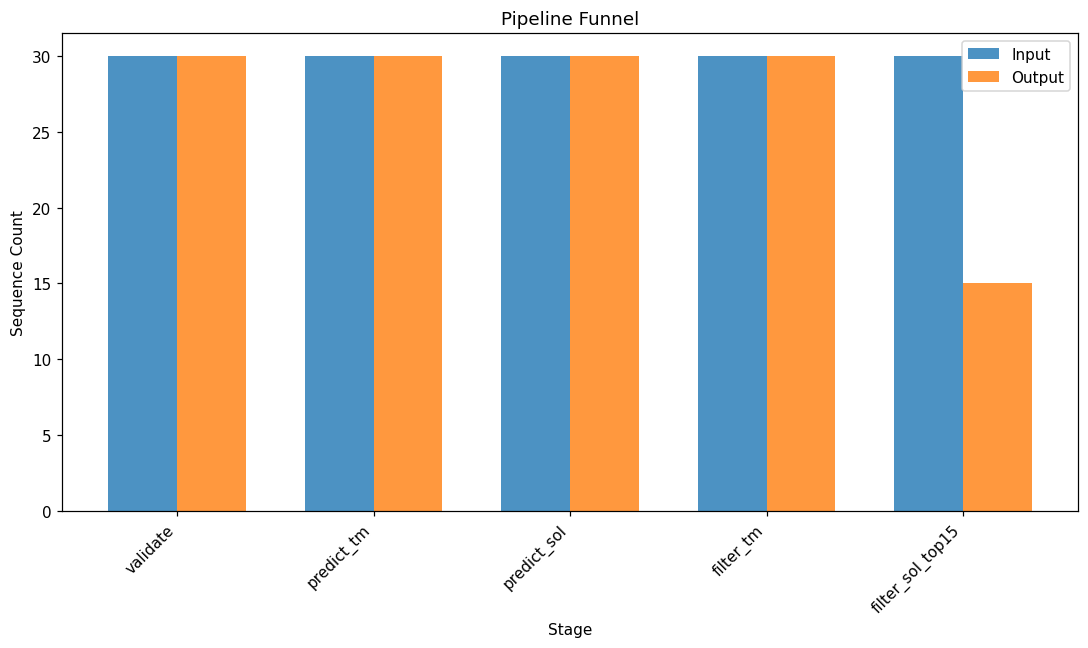

In [7]:
pipeline.plot("funnel")

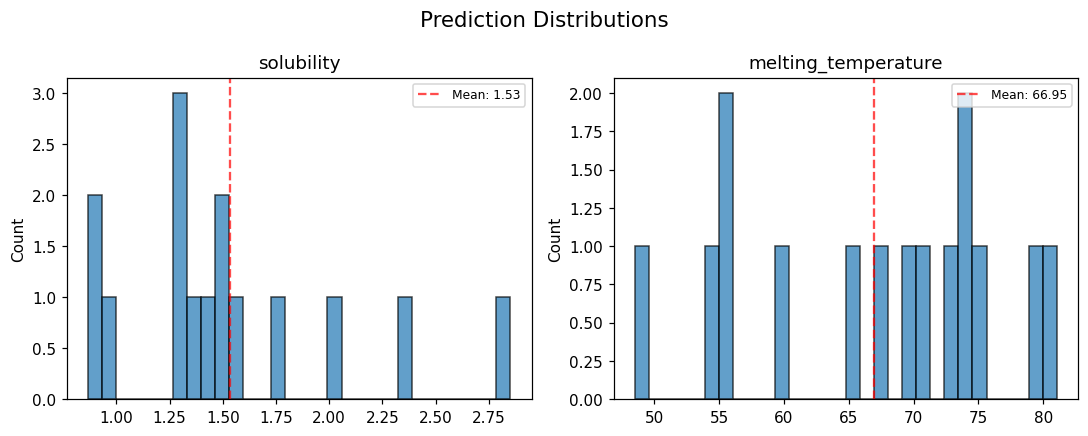

In [8]:
pipeline.plot("distributions")

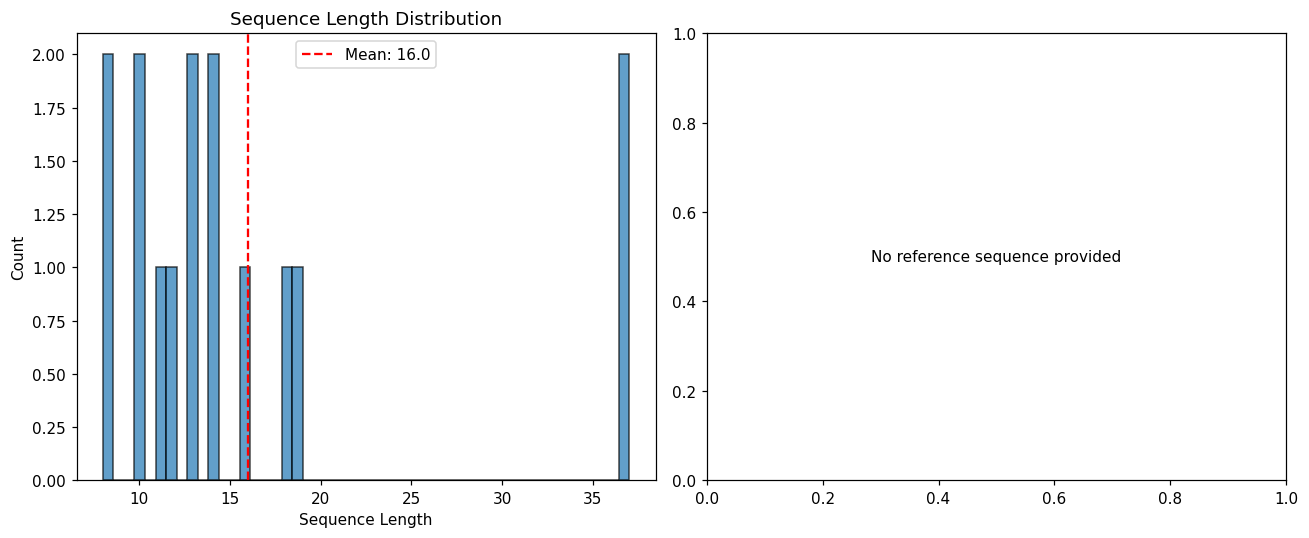

In [9]:
pipeline.plot("diversity")

## 5 — Scatter: Tm vs Solubility

SQL query to pivot predictions, then plot with filter survivors highlighted.

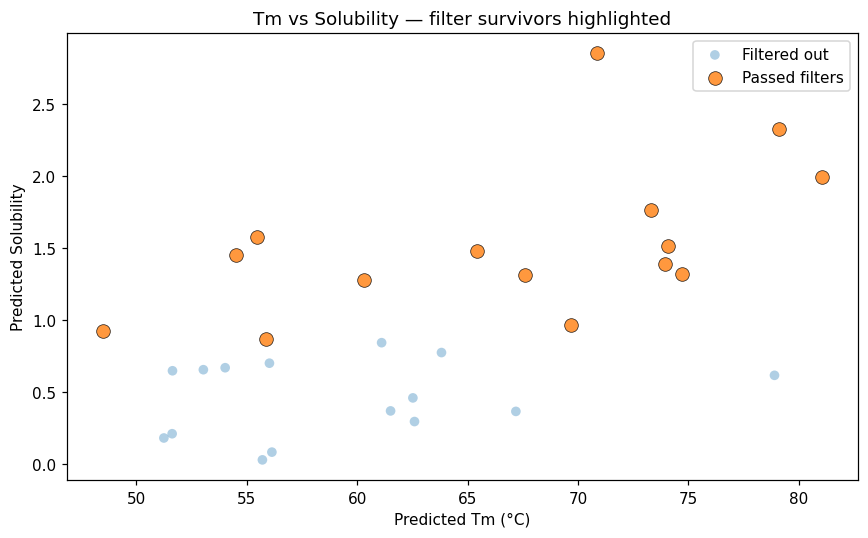

In [10]:
# Pivot predictions into wide format: one column per prediction type
scatter_df = pipeline.query("""
    SELECT s.sequence,
           MAX(CASE WHEN p.prediction_type = 'melting_temperature' THEN p.value END) AS tm,
           MAX(CASE WHEN p.prediction_type = 'solubility' THEN p.value END) AS solubility
    FROM sequences s
    JOIN predictions p ON s.sequence_id = p.sequence_id
    GROUP BY s.sequence
""")

# Get the final survivors (passed both filters)
survivors = set(pipeline.get_final_data()["sequence"].tolist())
scatter_df["survived"] = scatter_df["sequence"].isin(survivors)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for survived, group in scatter_df.groupby("survived"):
    ax.scatter(
        group["tm"], group["solubility"],
        label="Passed filters" if survived else "Filtered out",
        alpha=0.8 if survived else 0.35,
        s=80 if survived else 40,
        edgecolors="black" if survived else "none",
        linewidth=0.5,
    )
ax.set_xlabel("Predicted Tm (°C)")
ax.set_ylabel("Predicted Solubility")
ax.set_title("Tm vs Solubility — filter survivors highlighted")
ax.legend()
plt.tight_layout()
plt.show()

## 6 — Resume: zero API calls on cached data

Re-run the **exact same pipeline** on the same DuckDB. Before each prediction batch, the SDK runs a single SQL anti-join:

```sql
SELECT c.sequence_id FROM input_ids c
LEFT JOIN predictions p ON c.sequence_id = p.sequence_id
    AND p.prediction_type = ? AND p.model_name = ?
WHERE p.prediction_id IS NULL
```

If all sequences already have predictions → **zero API calls**. Only genuinely new sequences hit the API. This is what enables the **trickle pattern**: add new sequences to a growing campaign and only pay for the delta.

Watch the `Cached: 30/30` lines below — every prediction comes from disk.

In [11]:
# Re-run the exact same pipeline — everything is cached
pipeline2 = DataPipeline(
    sequences=PEPTIDES,
    datastore=ds,
    run_id="demo_v1",
    output_dir=str(OUTPUT_DIR),
    verbose=True,
)

pipeline2.add_filter(ValidAminoAcidFilter(verbose=True), stage_name="validate")
pipeline2.add_prediction(
    "temberture-regression", action="predict",
    extractions="prediction", columns="melting_temperature",
    stage_name="predict_tm", depends_on=["validate"], batch_size=16,
)
pipeline2.add_prediction(
    "biolmsol", action="predict",
    extractions="solubility_score", columns="solubility",
    stage_name="predict_sol", depends_on=["validate"], batch_size=16,
)
pipeline2.add_filter(
    ThresholdFilter("melting_temperature", min_value=40.0),
    stage_name="filter_tm", depends_on=["predict_tm", "predict_sol"],
)
pipeline2.add_filter(
    RankingFilter("solubility", n=15, ascending=False),
    stage_name="filter_sol_top15",
)

stage_results2 = pipeline2.run()
pipeline2.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('predict_tm', depends_on=['validate'])
Added stage: PredictionStage('predict_sol', depends_on=['validate'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol'])
Added stage: FilterStage('filter_sol_top15', depends_on=['filter_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: demo_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: predict_tm, predict_sol (parallel)
  Level 3: filter_tm
  Level 4: filter_sol_top15

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: predict_tm
Input: 30 sequences
Depends on: valid

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/1676896440.py:30: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  stage_results2 = pipeline2.run()


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,predict_tm,30,30,0,30,0,0.0
2,predict_sol,30,30,0,30,0,0.0
3,filter_tm,30,30,0,0,0,0.0
4,filter_sol_top15,30,15,15,0,0,0.0


## 7 — Clustering: ESM2 embeddings \u2192 K-means \u2192 PCA

Embed with ESM2-8m, cluster into 3 groups, visualize with PCA.

In [12]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_dir = OUTPUT_DIR / "cluster"
cluster_dir.mkdir(parents=True, exist_ok=True)
cluster_ds = DuckDBDataStore(cluster_dir / "pipeline.duckdb")

cp = DataPipeline(
    sequences=PEPTIDES,
    datastore=cluster_ds,
    run_id="cluster_v1",
    output_dir=str(cluster_dir),
    verbose=True,
)

cp.add_filter(ValidAminoAcidFilter(), stage_name="validate")

cp.add_prediction(
    "esm2-8m",
    action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed",
    depends_on=["validate"],
    batch_size=8,
    max_concurrent=4,
)

cp.add_clustering(
    method="kmeans",
    n_clusters=3,
    similarity_metric="embedding",
    embedding_model="esm2-8m",
    stage_name="cluster_k3",
    depends_on=["embed"],
)

cp.run()

cluster_df = cp.get_final_data()
print(f"\n{len(cluster_df)} sequences clustered")
cp.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: ClusteringStage('cluster_k3', depends_on=['embed'])

############################################################
# Pipeline: DataPipeline
# Run ID: cluster_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: cluster_k3

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/1703777465.py:37: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  cp.run()



StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 30 sequences
Depends on: validate
  Cached: 30/30
  To compute: 0

StageResult(embed: in=30, out=30, cached=30, computed=0, filtered=0, time=0.0s)

Stage: cluster_k3
Input: 30 sequences
Depends on: embed
  Clustering 30 sequences using kmeans...
  Loading embeddings from esm2-8m...
  Found 3 clusters
  Silhouette score: 0.246

StageResult(cluster_k3: in=30, out=30, cached=0, computed=30, filtered=0, time=0.2s)

############################################################
# Pipeline completed in 0.3s
# Final sequences: 30
############################################################


30 sequences clustered


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,embed,30,30,0,30,0,0.0
2,cluster_k3,30,30,0,0,30,0.2


Cluster sizes:
 cluster_id  n_sequences
          0           12
          1            5
          2           13

Silhouette score: 0.246


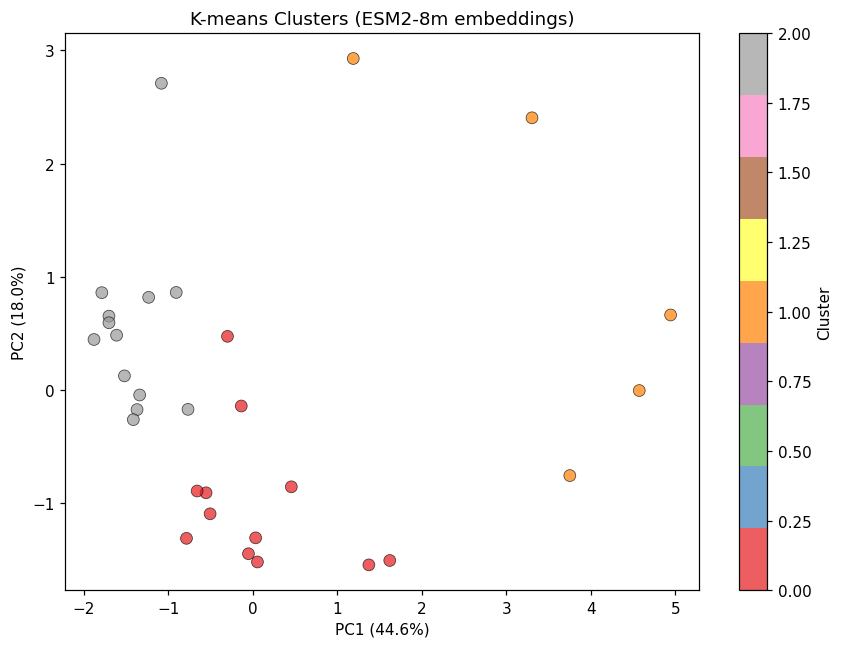

In [13]:
# Cluster sizes
cluster_sizes = cp.query("""
    SELECT CAST(p.value AS INTEGER) AS cluster_id, COUNT(*) AS n_sequences
    FROM predictions p
    WHERE p.prediction_type = 'cluster_k3'
    GROUP BY cluster_id
    ORDER BY cluster_id
""")
print("Cluster sizes:")
print(cluster_sizes.to_string(index=False))

# Get embeddings + labels for PCA
seq_ids = cluster_df["sequence_id"].tolist()
emb_map = cluster_ds.get_embeddings_bulk(seq_ids, model_name="esm2-8m")
ordered_ids = [sid for sid in seq_ids if sid in emb_map]
mat = np.stack([emb_map[sid] for sid in ordered_ids])

# Get cluster labels
label_df = cluster_ds.conn.execute("""
    SELECT sequence_id, CAST(value AS INTEGER) AS cluster_id
    FROM predictions WHERE prediction_type = 'cluster_k3'
""").df()
label_map = dict(zip(label_df["sequence_id"], label_df["cluster_id"]))
labels = np.array([label_map.get(sid, -1) for sid in ordered_ids])

# Silhouette score
valid = labels >= 0
if valid.sum() >= 3 and len(set(labels[valid])) >= 2:
    sil = silhouette_score(mat[valid], labels[valid])
    print(f"\nSilhouette score: {sil:.3f}")

# PCA plot
pca = PCA(n_components=2)
coords = pca.fit_transform(mat)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=labels, cmap="Set1", alpha=0.7, s=60,
    edgecolors="black", linewidth=0.5,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("K-means Clusters (ESM2-8m embeddings)")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

## 8 — Diversity sampling

Select maximally diverse representatives from the clustered sequences.

In [14]:
# Diversity sampling — pick maximally spread representatives from each cluster
from biolmai.pipeline import DiversitySamplingFilter

diverse_dir = OUTPUT_DIR / "diverse"
diverse_dir.mkdir(parents=True, exist_ok=True)
diverse_ds = DuckDBDataStore(diverse_dir / "pipeline.duckdb")

dp = DataPipeline(
    sequences=PEPTIDES,
    datastore=diverse_ds,
    run_id="diverse_v1",
    output_dir=str(diverse_dir),
    verbose=True,
)

dp.add_filter(ValidAminoAcidFilter(), stage_name="validate")

dp.add_prediction(
    "esm2-8m", action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed", depends_on=["validate"], batch_size=8,
)

dp.add_filter(
    DiversitySamplingFilter(n_samples=10, method="random"),
    stage_name="diverse_10",
    depends_on=["embed"],
)

dp.run()
diverse_df = dp.get_final_data()
print(f"Selected {len(diverse_df)} maximally diverse sequences from {len(PEPTIDES)}")
dp.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: FilterStage('diverse_10', depends_on=['embed'])

############################################################
# Pipeline: DataPipeline
# Run ID: diverse_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: diverse_10

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 30 sequences
Depends on: validate
  Cached: 30/30
  To compute: 0

StageResult(embed: in=30, out=30, cached=30, computed=0, filtered=0, time=0.0s)

Stage: diverse_10
Input: 30 sequences
Depends on: embed
  Applying filter: DiversitySamplingFilter(n=10, method='random')
  Filtered out: 2

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/67652776.py:30: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  dp.run()


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,embed,30,30,0,30,0,0.0
2,diverse_10,30,10,20,0,0,0.0


## 8b — Antibody pipelines: multi-column input

So far every example has been single-sequence input. But antibodies have **two chains** — heavy (VH) and light (VL). The pipeline supports multi-column input natively.

**How it works:**
1. Pass a DataFrame with your input columns (e.g., `heavy_chain`, `light_chain`)
2. Set `input_columns=["heavy_chain", "light_chain"]` — this tells the pipeline to hash on both columns for deduplication
3. Use `item_columns={"sequence": "heavy_chain"}` on prediction stages to control which column gets sent to the API as the `sequence` field

The sequences table in DuckDB gets both columns via `ALTER TABLE ADD COLUMN`, so SQL queries, filters, and `get_final_data()` all have access to both chains.

In [15]:
# Antibody VH/VL pairs — 4 therapeutic antibodies
ANTIBODY_VH = [
    "EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLEWVARIYPTNGYTRYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCSRWGGDGFYAMDYWGQGTLVTVSS",  # Trastuzumab VH
    "QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLEWVAVIWYDGSNKYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDRGIAAGGNYYYYGMDVWGQGTTVTVSS",  # Nivolumab VH
    "EVQLVESGGGLVQPGGSLRLSCAASGFTFSDSWIHWVRQAPGKGLEWVAWISPYGGSTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARRHWPGGFDYWGQGTLVTVSS",  # Bevacizumab VH
    "QVQLQQSGAELARPGASVKMSCKASGYTFTRYTMHWVKQRPGQGLEWIGYINPSRGYTNYNQKFKDKATLTTDKSSSTAYMQLSSLTSEDSAVYYCARYYDDHYCLDYWGQGTTLTVSS",  # Rituximab VH
]

ANTIBODY_VL = [
    "DIQMTQSPSSLSASVGDRVTITCRASQDVNTAVAWYQQKPGKAPKLLIYSASFLYSGVPSRFSGSRSGTDFTLTISSLQPEDFATYYCQQHYTTPPTFGQGTKVEIK",  # Trastuzumab VL
    "EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRLLIYDASNRATGIPARFSGSGSGTDFTLTISSLEPEDFAVYYCQQSSNWPRTFGQGTKVEIK",  # Nivolumab VL
    "DIQMTQSPSSLSASVGDRVTITCSASQDISNYLNWYQQKPGKAPKVLIYFTSSLHSGVPSRFSGSGSGTDFTLTISSLQPEDFATYYCQQYSTVPWTFGQGTKVEIK",  # Bevacizumab VL
    "QIVLSQSPAILSASPGEKVTMTCRASSSVSYIHWFQQKPGSSPKPWIYATSNLASGVPVRFSGSGSGTSYSLTISRVEAEDAATYYCQQWTSNPPTFGGGTKLEIN",  # Rituximab VL
]

# Build a DataFrame — this is the multi-column input
ab_input = pd.DataFrame({"heavy_chain": ANTIBODY_VH, "light_chain": ANTIBODY_VL})
print(f"{len(ab_input)} antibody pairs")
print(f"VH lengths: {[len(s) for s in ANTIBODY_VH]}")
print(f"VL lengths: {[len(s) for s in ANTIBODY_VL]}")
ab_input.head()

4 antibody pairs
VH lengths: [120, 126, 118, 119]
VL lengths: [107, 107, 107, 106]


,heavy_chain,light_chain
0,EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVNTAVAWYQQKPGKAPKL...
1,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...
2,EVQLVESGGGLVQPGGSLRLSCAASGFTFSDSWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCSASQDISNYLNWYQQKPGKAPKV...
3,QVQLQQSGAELARPGASVKMSCKASGYTFTRYTMHWVKQRPGQGLE...,QIVLSQSPAILSASPGEKVTMTCRASSSVSYIHWFQQKPGSSPKPW...


In [16]:
# Multi-column antibody pipeline
ab_dir = OUTPUT_DIR / "antibody"
ab_dir.mkdir(parents=True, exist_ok=True)
ab_ds = DuckDBDataStore(ab_dir / "pipeline.duckdb")

ab_pipeline = DataPipeline(
    sequences=ab_input,                              # DataFrame input (not a list of strings)
    input_columns=["heavy_chain", "light_chain"],    # both columns define a unique row
    datastore=ab_ds,
    run_id="antibody_v1",
    verbose=True,
)

# Predict Tm on the heavy chain only
# item_columns maps API field names → DataFrame column names
# temberture-regression expects {"sequence": "..."} so we map sequence → heavy_chain
ab_pipeline.add_prediction(
    "temberture-regression",
    action="predict",
    extractions="prediction",
    columns="vh_tm",
    stage_name="predict_vh_tm",
    item_columns={"sequence": "heavy_chain"},  # send heavy_chain as "sequence" to the API
    batch_size=4,
)

# Also predict Tm on the light chain
ab_pipeline.add_prediction(
    "temberture-regression",
    action="predict",
    extractions="prediction",
    columns="vl_tm",
    stage_name="predict_vl_tm",
    item_columns={"sequence": "light_chain"},  # send light_chain as "sequence"
    batch_size=4,
)

ab_pipeline.run()

ab_df = ab_pipeline.get_final_data()
print(f"\n{len(ab_df)} antibodies with predictions")
print(f"Columns: {ab_df.columns.tolist()}")
ab_pipeline.summary()

Added stage: PredictionStage('predict_vh_tm')
Added stage: PredictionStage('predict_vl_tm', depends_on=['predict_vh_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: antibody_v1
# Initial sequences: 4
# Streaming: ENABLED
############################################################

Execution plan: 2 level(s)
  Level 1: predict_vh_tm
  Level 2: predict_vl_tm

Stage: predict_vh_tm
Input: 4 sequences


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/3442298529.py:38: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  ab_pipeline.run()


  Cached: 4/4
  To compute: 0

StageResult(predict_vh_tm: in=4, out=4, cached=4, computed=0, filtered=0, time=0.0s)

Stage: predict_vl_tm
Input: 4 sequences
Depends on: predict_vh_tm
  Cached: 4/4
  To compute: 0

StageResult(predict_vl_tm: in=4, out=4, cached=4, computed=0, filtered=0, time=0.0s)

############################################################
# Pipeline completed in 0.0s
# Final sequences: 4
############################################################


4 antibodies with predictions
Columns: ['sequence_id', 'sequence', 'length', 'hash', 'heavy_chain', 'light_chain', 'vh_tm', 'vl_tm']


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,predict_vh_tm,4,4,0,4,0,0.0
1,predict_vl_tm,4,4,0,4,0,0.0


In [17]:
# Compare VH vs VL thermal stability
print("Antibody Tm predictions (VH vs VL):")
print("-" * 70)
for _, row in ab_df.iterrows():
    vh_short = row["heavy_chain"][:30] + "..."
    vl_short = row["light_chain"][:30] + "..."
    print(f"  VH: {vh_short}  Tm={row['vh_tm']:.1f}°C")
    print(f"  VL: {vl_short}  Tm={row['vl_tm']:.1f}°C")
    print(f"  ΔTm (VH-VL): {row['vh_tm'] - row['vl_tm']:+.1f}°C")
    print()

# SQL query across both chains
ab_pipeline.query("""
    SELECT
        s.heavy_chain,
        s.light_chain,
        vh.value AS vh_tm,
        vl.value AS vl_tm,
        vh.value - vl.value AS delta_tm
    FROM sequences s
    JOIN predictions vh ON s.sequence_id = vh.sequence_id AND vh.prediction_type = 'vh_tm'
    JOIN predictions vl ON s.sequence_id = vl.sequence_id AND vl.prediction_type = 'vl_tm'
    ORDER BY vh.value DESC
""")

Antibody Tm predictions (VH vs VL):
----------------------------------------------------------------------
  VH: EVQLVESGGGLVQPGGSLRLSCAASGFNIK...  Tm=55.5°C
  VL: DIQMTQSPSSLSASVGDRVTITCRASQDVN...  Tm=54.3°C
  ΔTm (VH-VL): +1.2°C

  VH: QVQLVESGGGVVQPGRSLRLSCAASGFTFS...  Tm=57.7°C
  VL: EIVLTQSPATLSLSPGERATLSCRASQSVS...  Tm=55.5°C
  ΔTm (VH-VL): +2.3°C

  VH: QVQLQQSGAELARPGASVKMSCKASGYTFT...  Tm=53.8°C
  VL: QIVLSQSPAILSASPGEKVTMTCRASSSVS...  Tm=52.2°C
  ΔTm (VH-VL): +1.5°C

  VH: EVQLVESGGGLVQPGGSLRLSCAASGFTFS...  Tm=54.8°C
  VL: DIQMTQSPSSLSASVGDRVTITCSASQDIS...  Tm=54.7°C
  ΔTm (VH-VL): +0.2°C



,heavy_chain,light_chain,vh_tm,vl_tm,delta_tm
0,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,57.746593,55.483429,2.263165
1,EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVNTAVAWYQQKPGKAPKL...,55.505753,54.303215,1.202538
2,EVQLLESGGGLVQPGGSLRLSCAASGFTFSSYAMSWVRQAPGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,55.012512,54.506054,0.506458
3,EVQLVESGGGLVQPGGSLRLSCAASGFTFSDSWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCSASQDISNYLNWYQQKPGKAPKV...,54.836834,54.657440,0.179394
4,QVQLQQSGAELARPGASVKMSCKASGYTFTRYTMHWVKQRPGQGLE...,QIVLSQSPAILSASPGEKVTMTCRASSSVSYIHWFQQKPGSSPKPW...,53.756130,52.213631,1.542500
5,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,53.485260,53.933697,-0.448437


## 8c — The trickle pattern: adding new sequences

A collaborator sends 2 more antibodies. We don't rebuild the pipeline — we feed all 6 into the **same DuckDB**. The 4 existing antibodies are served from cache; only the 2 new ones hit the API.

This is the core value proposition for long-running campaigns: **your database grows, your API bill doesn't.**

In [18]:
# 2 new antibodies arrive
NEW_VH = [
    "QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLEWMGGIIPIFGTANYAQKFQGRVTITADESTSTAYMELSSLRSEDTAVYYCARGLWDVADYWGQGTLVTVSS",  # Adalimumab VH
    "EVQLLESGGGLVQPGGSLRLSCAASGFTFSSYAMSWVRQAPGKGLEWVSAISGSGGSTYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAKDKILWFGEPVFDYWGQGTLVTVSS",  # Pembrolizumab VH
]
NEW_VL = [
    "DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKLLIYAASTLQSGVPSRFSGSGSGTDFTLTISSLQPEDVATYYCQRYNRAPYTFGQGTKVEIK",  # Adalimumab VL
    "EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRLLIYDASNRATGIPARFSGSGSGTDFTLTISSLEPEDFAVYYCQQRSNWPITFGQGTRLEIK",  # Pembrolizumab VL
]

# Combine old + new into one DataFrame
all_vh = ANTIBODY_VH + NEW_VH
all_vl = ANTIBODY_VL + NEW_VL
all_ab = pd.DataFrame({"heavy_chain": all_vh, "light_chain": all_vl})

# Run on the SAME datastore — cache kicks in for the original 4
ab_pipeline2 = DataPipeline(
    sequences=all_ab,
    input_columns=["heavy_chain", "light_chain"],
    datastore=ab_ds,  # same DuckDB file!
    run_id="antibody_v2",
    verbose=True,
)
ab_pipeline2.add_prediction(
    "temberture-regression", extractions="prediction", columns="vh_tm",
    stage_name="predict_vh_tm", item_columns={"sequence": "heavy_chain"}, batch_size=4,
)
ab_pipeline2.add_prediction(
    "temberture-regression", extractions="prediction", columns="vl_tm",
    stage_name="predict_vl_tm", item_columns={"sequence": "light_chain"}, batch_size=4,
)

ab_pipeline2.run()

# Notice: Cached=4, Computed=2 for each stage
print("\nTrickle results:")
ab_pipeline2.summary()

Added stage: PredictionStage('predict_vh_tm')
Added stage: PredictionStage('predict_vl_tm', depends_on=['predict_vh_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: antibody_v2
# Initial sequences: 6
# Streaming: ENABLED
############################################################

Execution plan: 2 level(s)
  Level 1: predict_vh_tm
  Level 2: predict_vl_tm

Stage: predict_vh_tm
Input: 6 sequences
  Cached: 6/6
  To compute: 0

StageResult(predict_vh_tm: in=6, out=6, cached=6, computed=0, filtered=0, time=0.0s)

Stage: predict_vl_tm
Input: 6 sequences
Depends on: predict_vh_tm
  Cached: 6/6
  To compute: 0

StageResult(predict_vl_tm: in=6, out=6, cached=6, computed=0, filtered=0, time=0.0s)

############################################################
# Pipeline completed in 0.0s
# Final sequences: 6
############################################################


Trickle results:


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/3520451410.py:33: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  ab_pipeline2.run()


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,predict_vh_tm,6,6,0,6,0,0.0
1,predict_vl_tm,6,6,0,6,0,0.0


## 9 — SPURS: structure-aware ΔΔG saturation mutagenesis (fully in-pipeline)

SPURS predicts the ΔΔG (change in folding free energy) for **every possible single-residue substitution** — a full deep mutational scanning (DMS) matrix from one API call.

It requires both the amino acid `sequence` **and** a PDB `structure` as input. We use `StructureSpec` to auto-store ESMFold's PDB output, and `structure_input` to inject it into SPURS — no manual API calls needed.

The DMS matrix is stored as individual prediction rows in DuckDB via `MatrixExtractionSpec`, enabling SQL queries and heatmap reconstruction directly from the cache.

In [19]:
from biolmai.pipeline import StructureSpec, MatrixExtractionSpec

# ── ESMFold → SPURS: two-stage pipeline ──
# StructureSpec tells the pipeline to store ESMFold's PDB output.
# structure_input tells SPURS to read it. MatrixExtractionSpec flattens
# the 2D DMS matrix into individual prediction rows in DuckDB.

SPURS_PEPTIDES = sorted(PEPTIDES, key=len, reverse=True)[:5]
print(f"SPURS input: {len(SPURS_PEPTIDES)} peptides (longest first)")

spurs_dir = OUTPUT_DIR / "spurs"
spurs_dir.mkdir(parents=True, exist_ok=True)
spurs_ds = DuckDBDataStore(spurs_dir / "pipeline.duckdb")

sp = DataPipeline(
    sequences=SPURS_PEPTIDES,
    datastore=spurs_ds,
    run_id="spurs_demo",
    verbose=True,
)

# Stage 1: Fold with ESMFold — stores PDB in structures table + pLDDT as scalar
sp.add_prediction(
    "esmfold",
    extractions="mean_plddt", columns="plddt",
    structure_output=StructureSpec(key="pdb", plddt_key="mean_plddt"),
    stage_name="fold",
    batch_size=1,
)

# Stage 2: SPURS full DMS — reads PDB from ESMFold, stores per-mutation ΔΔG
sp.add_prediction(
    "spurs",
    matrix_extraction=MatrixExtractionSpec(
        prefix="ddg",
        values_key="ddG_matrix.values",
        row_labels_key="ddG_matrix.residue_axis",
        col_labels_key="ddG_matrix.amino_acid_axis",
    ),
    structure_input={"pdb": "esmfold"},
    stage_name="spurs_dms",
    depends_on=["fold"],
    batch_size=1,
)

sp.run()
sp.summary()

SPURS input: 5 peptides (longest first)
Added stage: PredictionStage('fold')
Added stage: PredictionStage('spurs_dms', depends_on=['fold'])

############################################################
# Pipeline: DataPipeline
# Run ID: spurs_demo
# Initial sequences: 5
# Streaming: ENABLED
############################################################

Execution plan: 2 level(s)
  Level 1: fold
  Level 2: spurs_dms

Stage: fold
Input: 5 sequences
  Cached: 5/5
  To compute: 0

StageResult(fold: in=5, out=5, cached=5, computed=0, filtered=0, time=0.0s)

Stage: spurs_dms
Input: 5 sequences
Depends on: fold
  Cached: 5/5
  To compute: 0

StageResult(spurs_dms: in=5, out=5, cached=5, computed=0, filtered=0, time=0.0s)


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/3802852429.py:46: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  sp.run()



############################################################
# Pipeline completed in 0.0s
# Final sequences: 5
############################################################



,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,fold,5,5,0,5,0,0.0
1,spurs_dms,5,5,0,5,0,0.0


SPURS target: DHYNCVSSGGQCLYSACPIFTKIQGTCYRGKAKCCK... (36 aa)
DMS predictions: 720 rows


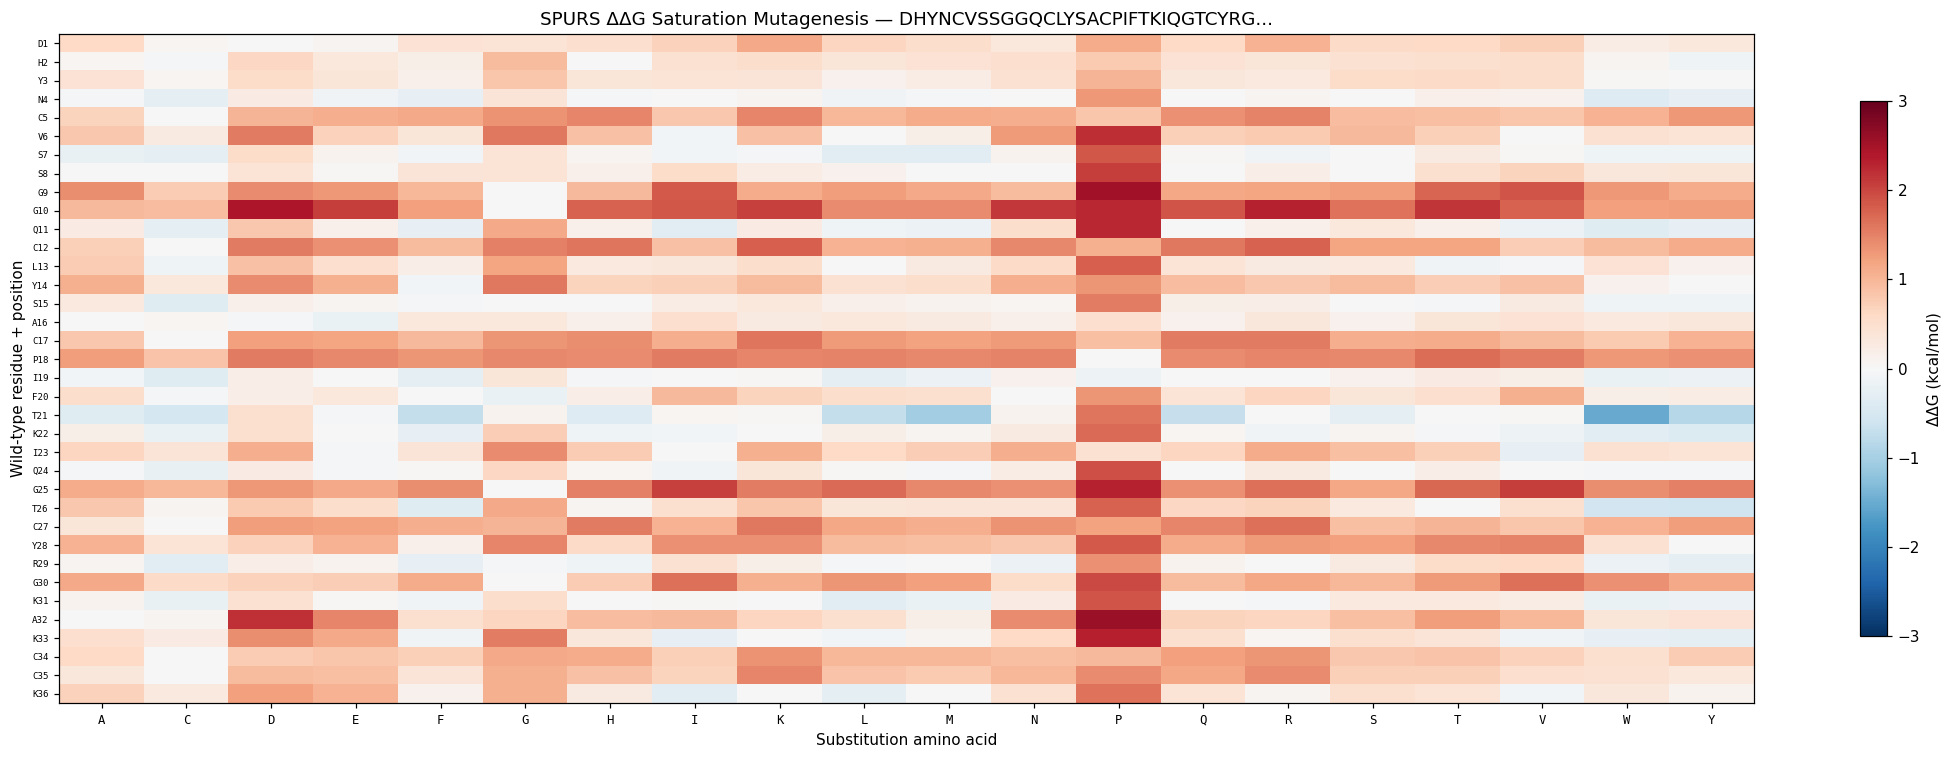


Mutation landscape:
  Stabilizing (ΔΔG < −0.5):   9 (1%)
  Neutral (|ΔΔG| ≤ 0.5):      362 (50%)
  Destabilizing (ΔΔG > +0.5):  349 (48%)


In [20]:
# ── SPURS DMS heatmap — reconstructed from DuckDB prediction rows ──
import re

# Pick the highest-pLDDT peptide
best_seq_id = spurs_ds.conn.execute("""
    SELECT sequence_id FROM predictions
    WHERE model_name = 'esmfold' AND prediction_type = 'plddt'
    ORDER BY value DESC LIMIT 1
""").fetchone()[0]

best_seq = spurs_ds.conn.execute(
    "SELECT sequence FROM sequences WHERE sequence_id = ?", [best_seq_id]
).fetchone()[0]

# Fetch all SPURS predictions for this sequence
dms = spurs_ds.conn.execute("""
    SELECT prediction_type, value FROM predictions
    WHERE sequence_id = ? AND model_name = 'spurs'
""", [best_seq_id]).df()

print(f"SPURS target: {best_seq[:40]}... ({len(best_seq)} aa)")
print(f"DMS predictions: {len(dms)} rows")

# Parse mutation notation back into (position_label, amino_acid) for heatmap
rows = []
for _, r in dms.iterrows():
    m = re.match(r'ddg_([A-Z]\d+)([A-Z])', r['prediction_type'])
    if m:
        rows.append({'position': m[1], 'aa': m[2], 'ddg': r['value']})

heatmap_df = pd.DataFrame(rows).pivot(index='position', columns='aa', values='ddg')

# Sort positions naturally (M1, K2, ..., not alphabetically)
pos_order = sorted(heatmap_df.index, key=lambda x: int(re.search(r'\d+', x).group()))
heatmap_df = heatmap_df.loc[pos_order]

fig, ax = plt.subplots(figsize=(min(22, len(heatmap_df) * 0.5 + 2), 7))
im = ax.imshow(heatmap_df.values, cmap='RdBu_r', aspect='auto',
               vmin=-3, vmax=3, interpolation='nearest')
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, fontsize=8, family='monospace')
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=6, family='monospace')
ax.set_xlabel('Substitution amino acid')
ax.set_ylabel('Wild-type residue + position')
ax.set_title(f'SPURS ΔΔG Saturation Mutagenesis — {best_seq[:30]}...')
plt.colorbar(im, ax=ax, label='ΔΔG (kcal/mol)', shrink=0.8)
plt.tight_layout()
plt.show()

# Summary statistics
ddg_values = heatmap_df.values
n_stabilizing = (ddg_values < -0.5).sum()
n_destabilizing = (ddg_values > 0.5).sum()
n_neutral = ddg_values.size - n_stabilizing - n_destabilizing
print(f"\nMutation landscape:")
print(f"  Stabilizing (ΔΔG < −0.5):   {n_stabilizing} ({n_stabilizing / ddg_values.size:.0%})")
print(f"  Neutral (|ΔΔG| ≤ 0.5):      {n_neutral} ({n_neutral / ddg_values.size:.0%})")
print(f"  Destabilizing (ΔΔG > +0.5):  {n_destabilizing} ({n_destabilizing / ddg_values.size:.0%})")

spurs_ds.close()

## 10 — Antibody design: AntiFold → ESMC scoring → ABodyBuilder3

This is the full antibody engineering pipeline:

1. **Generate** CDR variants with AntiFold (inverse folding conditioned on antibody structure)
2. **Score** each chain individually with ESMC-300M (log-probability — higher = more natural)
3. **Score** paired H+L with IgBERT-paired (antibody-specific language model)
4. **Filter** by ESMC log-probability (remove unnatural sequences)
5. **Predict structure** with ABodyBuilder3 (antibody-specific structure + pLDDT)

The dependency graph:
```
antifold_generate
   ├── esmc_vh_score  ─┐
   ├── esmc_vl_score  ─┤ (parallel — score each chain independently)
   └── igbert_score   ─┘
           ├── filter_esmc_vh
           └── filter_esmc_vl
                   └── abodybuilder3_structure
```

**Key concept: `item_columns`**
AntiFold generates paired H+L sequences. Downstream models see different columns:
- `esmc_vh_score` sends `heavy_chain` as `"sequence"`
- `esmc_vl_score` sends `light_chain` as `"sequence"`
- `igbert-paired` sends both `heavy_chain` as `"heavy"` and `light_chain` as `"light"`
- `abodybuilder3-plddt` sends `heavy_chain` as `"H"` and `light_chain` as `"L"`

In [21]:
from biolmai.pipeline import (
    DirectGenerationConfig,
    ExtractionSpec,
    GenerativePipeline,
    SequenceLengthFilter,
    StructureSpec,
)

# ── Step 1: Generate antibody variants with AntiFold ──
# AntiFold needs a PDB structure. We'll use a Trastuzumab Fab PDB.
AB_PDB_PATH = Path("../tests/fixtures/antibody_HL.pdb")
if not AB_PDB_PATH.exists():
    print(f"WARNING: {AB_PDB_PATH} not found — using antibody_fab.pdb as fallback")
    AB_PDB_PATH = Path("../tests/fixtures/antibody_fab.pdb")

print(f"Antibody PDB: {AB_PDB_PATH}")

ab_design_dir = OUTPUT_DIR / "ab_design"
ab_design_dir.mkdir(parents=True, exist_ok=True)
ab_design_ds = DuckDBDataStore(ab_design_dir / "pipeline.duckdb")

# AntiFold generation config — inverse folding on antibody structure
antifold_config = DirectGenerationConfig(
    model_name="antifold",
    structure_path=str(AB_PDB_PATH),
    item_field="pdb",
    params={
        "heavy_chain": "H",      # chain ID in PDB
        "light_chain": "L",      # chain ID in PDB
        "num_seq_per_target": 8,  # generate 8 H+L pairs
        "sampling_temp": 0.3,     # low temp = conservative CDR changes
    },
)

# Build the full pipeline: generate → score → filter → structure
ab_design = GenerativePipeline(
    generation_configs=[antifold_config],
    deduplicate=True,
    datastore=ab_design_ds,
    run_id="ab_design_v1",
    verbose=True,
)

# ── Step 2: ESMC scoring on individual chains (parallel) ──
# ESMC-300M scores sequence naturalness via log-probability
# Higher log_prob = more natural sequence (fewer surprising residues)

ab_design.add_prediction(
    "esmc-300m",
    action="score",
    extractions="log_prob",
    columns="vh_logprob",
    stage_name="esmc_vh_score",
    depends_on=["generation"],
    item_columns={"sequence": "heavy_chain"},  # score VH only
    batch_size=4,
)

ab_design.add_prediction(
    "esmc-300m",
    action="score",
    extractions="log_prob",
    columns="vl_logprob",
    stage_name="esmc_vl_score",
    depends_on=["generation"],
    item_columns={"sequence": "light_chain"},  # score VL only
    batch_size=4,
)

# ── Step 2b: IgBERT paired scoring ──
# IgBERT-paired evaluates the H+L pair together — captures inter-chain compatibility
ab_design.add_prediction(
    "igbert-paired",
    action="predict_log_prob",
    extractions="log_prob",
    columns="igbert_score",
    stage_name="igbert_score",
    depends_on=["generation"],
    item_columns={"heavy": "heavy_chain", "light": "light_chain"},  # both chains
    batch_size=4,
)

# ── Step 3: Filter by ESMC naturalness ──
# Drop sequences where either chain has very low log-probability
ab_design.add_filter(
    RankingFilter("vh_logprob", n=6, ascending=False),  # keep top 6 by VH naturalness
    stage_name="filter_vh",
    depends_on=["esmc_vh_score", "esmc_vl_score", "igbert_score"],
)

# ── Step 4: ABodyBuilder3 structure prediction ──
# Predict 3D structures — store PDB via StructureSpec + extract mean pLDDT
# params={"plddt": True} tells the API to include per-residue pLDDT in the response
ab_design.add_prediction(
    "abodybuilder3-plddt",
    action="predict",
    extractions=[ExtractionSpec("plddt", reduction="mean")],
    columns={"plddt": "ab_plddt"},
    structure_output=StructureSpec(key="pdb"),
    params={"plddt": True},
    stage_name="ab3_structure",
    depends_on=["filter_vh"],
    item_columns={"H": "heavy_chain", "L": "light_chain"},
    batch_size=2,
    max_concurrent=2,
)

ab_design.run()
ab_design.summary()

Antibody PDB: ../tests/fixtures/antibody_HL.pdb
Added stage: PredictionStage('esmc_vh_score', depends_on=['generation'])
Added stage: PredictionStage('esmc_vl_score', depends_on=['generation'])
Added stage: PredictionStage('igbert_score', depends_on=['generation'])
Added stage: FilterStage('filter_vh', depends_on=['esmc_vh_score', 'esmc_vl_score', 'igbert_score'])
Added stage: PredictionStage('ab3_structure', depends_on=['filter_vh'])

Stage: generation (Generation)
Configs: 1
  Generating with 1 model configuration(s)...


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/1620697425.py:108: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  ab_design.run()


  antifold (direct): generating sequences...
  Adding 8 sequences to datastore...

StageResult(generation: in=0, out=8, cached=0, computed=8, filtered=0, time=0.0s)

############################################################
# Pipeline: GenerativePipeline
# Run ID: ab_design_v1
# Initial sequences: 8
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: esmc_vh_score, esmc_vl_score, igbert_score (parallel)
  Level 2: filter_vh
  Level 3: ab3_structure

Executing 3 stages in parallel...

Stage: esmc_vh_score
Input: 8 sequences
  Cached: 0/8
  To compute: 8
  Calling esmc-300m.score...


  esmc-300m:   0%|          | 0/2 [00:00<?, ?batch/s]


Stage: esmc_vl_score
Input: 8 sequences
  Cached: 0/8
  To compute: 8
  Calling esmc-300m.score...


  esmc-300m:   0%|          | 0/2 [00:00<?, ?batch/s]


Stage: igbert_score
Input: 8 sequences
  Cached: 8/8
  To compute: 0

StageResult(igbert_score: in=8, out=8, cached=8, computed=0, filtered=0, time=0.0s)
  Completed: 8 sequences in 2 batches (max 5 concurrent)

StageResult(esmc_vl_score: in=8, out=8, cached=0, computed=8, filtered=0, time=24.9s)
  Completed: 8 sequences in 2 batches (max 5 concurrent)

StageResult(esmc_vh_score: in=8, out=8, cached=0, computed=8, filtered=0, time=27.4s)

Stage: filter_vh
Input: 8 sequences
Depends on: esmc_vh_score, esmc_vl_score, igbert_score
  Applying filter: RankingFilter(column='vh_logprob', n=6, method='top')
  Filtered out: 2/8
  Remaining: 6

StageResult(filter_vh: in=8, out=6, cached=0, computed=0, filtered=2, time=0.0s)

Stage: ab3_structure
Input: 6 sequences
Depends on: filter_vh
  Cached: 0/6
  To compute: 6
  Calling abodybuilder3-plddt.predict...


  abodybuilder3-plddt:   0%|          | 0/3 [00:00<?, ?batch/s]

  Completed: 6 sequences in 3 batches (max 2 concurrent)

StageResult(ab3_structure: in=6, out=6, cached=0, computed=6, filtered=0, time=55.4s)

############################################################
# Pipeline completed in 82.8s
# Final sequences: 6
############################################################



,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,esmc_vh_score,8,8,0,0,8,27.4
1,esmc_vl_score,8,8,0,0,8,24.9
2,igbert_score,8,8,0,8,0,0.0
3,filter_vh,8,6,2,0,0,0.0
4,ab3_structure,6,6,0,0,6,55.4
5,generation,0,8,0,0,8,0.0


In [22]:
# Inspect designed antibodies — rank by ABodyBuilder3 pLDDT
ab_design_df = ab_design.get_final_data()
print(f"{len(ab_design_df)} antibody designs passed all filters\n")

# Rank by ABodyBuilder3 mean pLDDT
ranked = ab_design.query("""
    SELECT
        s.sequence_id,
        s.heavy_chain,
        s.light_chain,
        vh_lp.value AS vh_logprob,
        vl_lp.value AS vl_logprob,
        ig.value AS igbert_score,
        ab.value AS ab_plddt,
        (vh_lp.value + vl_lp.value) AS combined_logprob
    FROM sequences s
    LEFT JOIN predictions vh_lp ON s.sequence_id = vh_lp.sequence_id AND vh_lp.prediction_type = 'vh_logprob'
    LEFT JOIN predictions vl_lp ON s.sequence_id = vl_lp.sequence_id AND vl_lp.prediction_type = 'vl_logprob'
    LEFT JOIN predictions ig ON s.sequence_id = ig.sequence_id AND ig.prediction_type = 'igbert_score'
    LEFT JOIN predictions ab ON s.sequence_id = ab.sequence_id AND ab.prediction_type = 'ab_plddt'
    ORDER BY ab.value DESC
""")

print("Designed antibodies (ranked by ABodyBuilder3 pLDDT):")
print("-" * 90)
for _, row in ranked.iterrows():
    plddt_str = f"pLDDT={row['ab_plddt']:.1f}" if row['ab_plddt'] is not None else "pLDDT=N/A"
    print(f"  seq_id={int(row['sequence_id'])}  {plddt_str}  "
          f"VH_LP={row['vh_logprob']:.2f}  VL_LP={row['vl_logprob']:.2f}  "
          f"IgBERT={row['igbert_score']:.3f}")
    print(f"       VH: {row['heavy_chain'][:50]}...")
    print(f"       VL: {row['light_chain'][:50]}...")
    print()

# Visualize the best antibody structure with py3Dmol
best_seq_id = int(ranked.iloc[0]["sequence_id"])
struct = ab_design_ds.get_structure(best_seq_id, "abodybuilder3-plddt")

if struct and struct.get("structure_str"):
    pdb_str = struct["structure_str"]
    print(f"Visualizing best antibody (seq_id={best_seq_id}): {len(pdb_str)} chars")

    try:
        import py3Dmol
        view = py3Dmol.view(width=800, height=500)
        view.addModel(pdb_str, "pdb")
        view.setStyle({"chain": "H"}, {"cartoon": {"color": "#3498db"}})  # VH in blue
        view.setStyle({"chain": "L"}, {"cartoon": {"color": "#e74c3c"}})  # VL in red
        view.zoomTo()
        view.show()
    except ImportError:
        print("py3Dmol not installed — run: pip install py3Dmol")
        print(f"PDB preview (first 5 lines):")
        for line in pdb_str.split("\n")[:5]:
            print(f"  {line}")
else:
    print(f"No structure found for seq_id={best_seq_id}")

ab_design_ds.close()

6 antibody designs passed all filters

Designed antibodies (ranked by ABodyBuilder3 pLDDT):
------------------------------------------------------------------------------------------
  seq_id=18  pLDDT=-3.6  VH_LP=-97.59  VL_LP=-187.01  IgBERT=nan
       VH: EVQLVESGGGLVQPGGSLRLSCAASGFTISSYYIHWVRQAPGKGLEWVAG...
       VL: DIQMTQSPSSLSASVGDRVTITCRASQGIGTAVAWYQQKPGKAPKLLIYS...

  seq_id=2  pLDDT=-3.6  VH_LP=-99.54  VL_LP=-183.33  IgBERT=nan
       VH: EVQLVESGGGLVQPGGSLRLSCAASGFTISDYYIHWVRQAPGKGLEWVAG...
       VL: DIQMTQSPSSLSASVGDRVTITCRASQGISTAVAWYQQKPGKAPKLLIYS...

  seq_id=19  pLDDT=-3.6  VH_LP=-97.59  VL_LP=-185.36  IgBERT=nan
       VH: EVQLVESGGGLVQPGGSLRLSCAASGFTISSYYIHWVRQAPGKGLEWVAG...
       VL: DIQMTQSPSSLSASVGDRVTITCRASQGIGTAVAWYQQKPGKAPKLLIYS...

  seq_id=21  pLDDT=-3.6  VH_LP=-99.47  VL_LP=-180.87  IgBERT=nan
       VH: EVQLVESGGGLVQPGGSLRLSCAASGFTINSYYIHWVRQAPGKGLEWVAG...
       VL: DIQMTQSPSSLSASVGDRVTITCRASQGISTAVAWYQQKPGKAPKLLIYS...

  seq_id=16  pLDDT=-3.6  VH_LP=-97

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 11 — PETase design: 7 generative models → score → filter

Design variants of **LCC** (Leaf-branch Compost Cutinase), one of the most active PET-degrading enzymes (EC 3.1.1.101).

**7 generation sources** — each explores sequence space differently:

| Model | Method | Input | What it captures |
|---|---|---|---|
| `zymctrl` | EC-conditioned | `3.1.1.101` | Enzyme functional class (de novo PETases) |
| `progen2-oas` | Autoregressive | N-terminal seed | De novo generation seeded by LCC |
| `protein-mpnn` (T=0.1) | Inverse folding | ESMFold PDB | Conservative structure-preserving variants |
| `protein-mpnn` (T=0.3) | Inverse folding | ESMFold PDB | More diverse structure-preserving variants |
| `hyper-mpnn` (T=0.2) | Hypernetwork MPNN | ESMFold PDB | Neural-net-enhanced inverse folding |
| ESMC `RemaskingConfig` | Masked-LM refinement | Parent sequence | ESMC-guided evolutionary mutations |
| DSM-150M `RemaskingConfig` | Diffusion refinement | Parent sequence | Diffusion-model-guided mutations |

**MLM Remasking** is a unique generation strategy: it masks a fraction of positions in the parent sequence, asks a language model to infill them, then iterates. This produces variants that stay close to the parent but explore mutations the model considers plausible. You can control:
- `mask_fraction` — what % of positions to mask (0.15 = 15%)
- `num_iterations` — how many mask→fill rounds (more iterations = more divergence)
- `conserved_positions` — positions that must NOT be mutated (e.g., active site residues)
- `mask_strategy` — `"random"`, `"blocks"` (contiguous regions), or `"structured"`

Using two different remasking models (ESMC vs DSM) on the same parent lets you compare which language model produces more viable variants — a built-in ablation study.

Presets: `CONSERVATIVE_CONFIG` (10% masked), `MODERATE_CONFIG` (15%), `AGGRESSIVE_CONFIG` (20%).

All 7 configs fire in parallel. After generation, the pipeline deduplicates and runs 3 scoring models in parallel:
- `temberture-regression` — Tm (PETases need ≥65°C for industrial PET recycling)
- `biolmsol` — solubility
- `esmc-300m` — log-probability (evolutionary plausibility)

Then filters: Tm > 55°C → top 15 by solubility.

In [23]:
# ── PETase multi-model generation pipeline ──
from biolmai.pipeline import RemaskingConfig

# LCC PETase — Leaf-branch Compost Cutinase (mature form)
LCC_SEQUENCE = (
    "SNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVGAIAIVPGYT"
    "ARQSSIKWWGPRLASHGFVVITIDTNSTLDQPSSRSSQQMAALRQVASLNGTSSSPIYGK"
    "VDTARMGVMGWSMGGGGSLISAANNPSLKAAAPQAPWDSSTNFSSVTVPTLIFACENDSI"
    "APVNSSALPIYDSMSRNAKQFLEINGGSHSCANSGNSNQALIGKKGVAWMKRFMDNDTRY"
    "STFACENPNSTRVSDFRTANCS"
)

# Step 1: Fold LCC to get a PDB structure for MPNN
print("Step 1: Folding LCC with ESMFold...")
fold_api = BioLMApiClient("esmfold")

async def fold_lcc():
    result = await fold_api.predict(items=[{"sequence": LCC_SEQUENCE}])
    await fold_api.shutdown()
    r = result[0] if isinstance(result, list) else result
    return r["pdb"], r["mean_plddt"], r["ptm"]

lcc_pdb, lcc_plddt, lcc_ptm = asyncio.get_event_loop().run_until_complete(fold_lcc())
print(f"  LCC folded: pLDDT={lcc_plddt:.1f}  pTM={lcc_ptm:.3f}  PDB={len(lcc_pdb)} chars")

# Step 2: Build generation configs — 7 different strategies
N_PER_MODEL = 5  # keep small for demo speed

# Catalytic triad positions (0-indexed): Ser165, Asp210, His242
CATALYTIC_TRIAD = [164, 209, 241]

configs = [
    # 1. ZymCTRL — EC-conditioned enzyme generation
    DirectGenerationConfig(
        model_name="zymctrl",
        item_field="ec_number",
        sequence="3.1.1.101",  # PETase EC number
        params={"temperature": 1.0, "max_length": 300},
    ),
    # 2. ProGen2-OAS — autoregressive from N-terminal seed
    DirectGenerationConfig(
        model_name="progen2-oas",
        item_field="context",
        sequence=LCC_SEQUENCE[:25],  # N-terminal seed
        params={"temperature": 1.0, "max_length": len(LCC_SEQUENCE) + 20},
    ),
    # 3. ProteinMPNN T=0.1 — conservative inverse folding
    DirectGenerationConfig(
        model_name="protein-mpnn",
        item_field="pdb",
        sequence=lcc_pdb,
        params={"batch_size": N_PER_MODEL, "temperature": 0.1},
    ),
    # 4. ProteinMPNN T=0.3 — more diverse inverse folding
    DirectGenerationConfig(
        model_name="protein-mpnn",
        item_field="pdb",
        sequence=lcc_pdb,
        params={"batch_size": N_PER_MODEL, "temperature": 0.3},
    ),
    # 5. HyperMPNN T=0.2 — hypernetwork MPNN variant
    DirectGenerationConfig(
        model_name="hyper-mpnn",
        item_field="pdb",
        sequence=lcc_pdb,
        params={"batch_size": N_PER_MODEL, "temperature": 0.2},
    ),
    # 6. ESMC Remasking — masked-LM refinement with ESMC-300M
    # Masks 15% of positions, infills with ESMC, iterates 3 times.
    # conserved_positions protects the catalytic triad.
    RemaskingConfig(
        mask_fraction=0.15,
        num_iterations=3,
        conserved_positions=CATALYTIC_TRIAD,
        mask_strategy="random",
        model_name="esmc-300m",
        parent_sequence=LCC_SEQUENCE,
        num_variants=N_PER_MODEL,
    ),
    # 7. DSM-150M Remasking — diffusion-model refinement
    # Same mask strategy but uses the diffusion sequence model.
    # Comparing ESMC vs DSM remasking is a built-in ablation.
    RemaskingConfig(
        mask_fraction=0.15,
        num_iterations=3,
        conserved_positions=CATALYTIC_TRIAD,
        mask_strategy="random",
        model_name="dsm-150m-base",
        action="generate",
        parent_sequence=LCC_SEQUENCE,
        num_variants=N_PER_MODEL,
    ),
]

print(f"\n{len(configs)} generation configs:")
for cfg in configs:
    name = cfg.model_name if hasattr(cfg, 'model_name') else type(cfg).__name__
    print(f"  {name}")

# Step 3: Build generative pipeline with downstream scoring
petase_dir = OUTPUT_DIR / "petase"
petase_dir.mkdir(parents=True, exist_ok=True)
petase_ds = DuckDBDataStore(petase_dir / "pipeline.duckdb")

petase = GenerativePipeline(
    generation_configs=configs,
    deduplicate=True,
    datastore=petase_ds,
    run_id="petase_v1",
    verbose=True,
)

# Length filter — PETases are ~250-300 aa
petase.add_filter(
    SequenceLengthFilter(min_length=100, max_length=500),
    stage_name="filter_length",
    depends_on=["generation"],
)

# Parallel scoring: Tm + solubility + log-probability
petase.add_prediction(
    "temberture-regression", extractions="prediction", columns="tm",
    stage_name="predict_tm", depends_on=["filter_length"],
)
petase.add_prediction(
    "biolmsol", extractions="solubility_score", columns="solubility",
    stage_name="predict_sol", depends_on=["filter_length"],
)
petase.add_prediction(
    "esmc-300m", action="score", extractions="log_prob", columns="log_prob",
    stage_name="score_lp", depends_on=["filter_length"],
)

# Filter: Tm > 55°C then top 15 by solubility
petase.add_filter(
    ThresholdFilter("tm", min_value=55.0),
    stage_name="filter_tm",
    depends_on=["predict_tm", "predict_sol", "score_lp"],
)
petase.add_filter(
    RankingFilter("solubility", n=15, ascending=False),
    stage_name="rank_sol",
    depends_on=["filter_tm"],
)

# Embed all length-valid sequences — parallel with predictions, for PCA coloring
petase.add_prediction(
    "esm2-8m",
    action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed_petase",
    depends_on=["filter_length"],
    batch_size=8,
    max_concurrent=4,
)

petase.run()
petase.summary()

Step 1: Folding LCC with ESMFold...
  LCC folded: pLDDT=90.3  pTM=0.938  PDB=155886 chars

7 generation configs:
  zymctrl
  progen2-oas
  protein-mpnn
  protein-mpnn
  hyper-mpnn
  esmc-300m
  dsm-150m-base
Added stage: FilterStage('filter_length', depends_on=['generation'])
Added stage: PredictionStage('predict_tm', depends_on=['filter_length'])
Added stage: PredictionStage('predict_sol', depends_on=['filter_length'])
Added stage: PredictionStage('score_lp', depends_on=['filter_length'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol', 'score_lp'])
Added stage: FilterStage('rank_sol', depends_on=['filter_tm'])

Stage: generation (Generation)
Configs: 7
  Generating with 7 model configuration(s)...
  zymctrl (direct): generating sequences...
  progen2-oas (direct): generating sequences...
  protein-mpnn (direct): generating sequences...
  protein-mpnn (direct): generating sequences...
  hyper-mpnn (direct): generating sequences...
  esmc-300m (remasking):

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/3448186959.py:146: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  petase.run()


  Adding 31 sequences to datastore...

StageResult(generation: in=0, out=31, cached=0, computed=31, filtered=0, time=0.0s)

############################################################
# Pipeline: GenerativePipeline
# Run ID: petase_v1
# Initial sequences: 31
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: filter_length
  Level 2: predict_tm, predict_sol, score_lp (parallel)
  Level 3: filter_tm
  Level 4: rank_sol

Stage: filter_length
Input: 31 sequences
  Applying filter: SequenceLengthFilter(min=100, max=500)
  Filtered out: 0/31
  Remaining: 31

StageResult(filter_length: in=31, out=31, cached=0, computed=0, filtered=0, time=0.0s)

Executing 3 stages in parallel...

Stage: predict_tm
Input: 31 sequences
Depends on: filter_length
  Cached: 0/31
  To compute: 31
  Calling temberture-regression.predict...

Stage: predict_sol
Input: 31 sequences
Depends on: filter_length
  Cached: 0/31
  To compute: 31
  Calling 

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,filter_length,31,31,0,0,0,0.0
1,predict_tm,31,31,0,0,31,73.9
2,predict_sol,31,31,0,0,31,66.2
3,score_lp,31,31,0,0,31,38.0
4,filter_tm,31,7,24,0,0,0.0
5,rank_sol,7,7,0,0,0,0.0
6,generation,0,31,0,0,31,0.0


In [24]:
# Inspect PETase candidates
petase_df = petase.get_final_data()
print(f"{len(petase_df)} PETase candidates survived all filters\n")

# Add LCC parent for comparison
lcc_row = petase.query(f"""
    SELECT s.sequence, s.length,
           tm.value AS tm, sol.value AS solubility, lp.value AS log_prob
    FROM sequences s
    LEFT JOIN predictions tm ON s.sequence_id = tm.sequence_id AND tm.prediction_type = 'tm'
    LEFT JOIN predictions sol ON s.sequence_id = sol.sequence_id AND sol.prediction_type = 'solubility'
    LEFT JOIN predictions lp ON s.sequence_id = lp.sequence_id AND lp.prediction_type = 'log_prob'
    WHERE s.sequence = '{LCC_SEQUENCE}'
""")
if len(lcc_row) > 0:
    print("LCC parent (reference):")
    print(f"  Tm={lcc_row.iloc[0]['tm']:.1f}°C  Sol={lcc_row.iloc[0]['solubility']:.3f}  LP={lcc_row.iloc[0]['log_prob']:.1f}")

# Top candidates
top = petase.query("""
    SELECT s.sequence, s.length,
           tm.value AS tm, sol.value AS solubility, lp.value AS log_prob
    FROM sequences s
    JOIN predictions tm ON s.sequence_id = tm.sequence_id AND tm.prediction_type = 'tm'
    JOIN predictions sol ON s.sequence_id = sol.sequence_id AND sol.prediction_type = 'solubility'
    JOIN predictions lp ON s.sequence_id = lp.sequence_id AND lp.prediction_type = 'log_prob'
    ORDER BY sol.value DESC
    LIMIT 10
""")

print(f"\nTop 10 PETase candidates (by solubility):")
print(f"  {'#':>3}  {'Len':>4}  {'Tm':>6}  {'Sol':>6}  {'LP':>8}  Sequence")
print(f"  {'---':>3}  {'---':>4}  {'---':>6}  {'---':>6}  {'---':>8}  --------")
for i, row in top.iterrows():
    tag = " ← LCC" if row["sequence"] == LCC_SEQUENCE else ""
    print(f"  {i+1:>3}  {row['length']:>4}  {row['tm']:>6.1f}  {row['solubility']:>6.3f}  "
          f"{row['log_prob']:>8.1f}  {row['sequence'][:40]}...{tag}")

# Per-model breakdown (if generation metadata available)
model_breakdown = petase.query("""
    SELECT gm.model_name, COUNT(*) AS n_generated
    FROM generation_metadata gm
    GROUP BY gm.model_name
    ORDER BY n_generated DESC
""")
if len(model_breakdown) > 0:
    print(f"\nPer-model generation counts:")
    for _, row in model_breakdown.iterrows():
        print(f"  {row['model_name']}: {row['n_generated']}")

print(f"\nPETase DB path: {petase_dir / 'pipeline.duckdb'}")
print("(We'll use this DB for the from_db() recovery demo next)")
# Don't close petase_ds yet — we need it for the resume demo

7 PETase candidates survived all filters


Top 10 PETase candidates (by solubility):
    #   Len      Tm     Sol        LP  Sequence
  ---   ---     ---     ---       ---  --------
    1   291    50.4   0.657    -639.1  MKIFIFFLFTVGLASSSLPEQPPKNPSPVKVSERDAKSDL...
    2   291    51.6   0.540    -683.9  MKLSALTIVLTAFVQCEPNPEKSSDPPKKPKVLSSPAVLA...
    3   291    52.3   0.469    -675.5  MASIRTLFVGTCAAITLLLLSATAFTAEPVVEVQTENVKQ...
    4   291    53.1   0.467    -695.9  MLGKAVRAASAVFILLGGTSLAPADESPAALLAGVQQARQ...
    5   262    73.0   0.254    -387.8  MNEGARGPEPTRELLESPYGPYRVASFEIDNPVGFGKGVV...
    6   262    77.5   0.233    -379.1  MDEGAAGPEPTRELLEAPRGPYRVESFEVKNPEGFGTAVV...
    7   262    64.1   0.224    -392.6  MNEGAAGPEPTRELLEAPRGPYKVESFEVKNPKGFGEAVV...
    8   262    54.5   0.217    -410.0  MNRGAAGPEPTRELLEAPRGPFKVASFRVDNPRGFGRGVV...
    9   262    76.1   0.188    -394.3  MDRGAAGPEPTRELLEAPRGPYRVESFEVDSPEGFGRAVV...
   10   262    78.7   0.185    -402.9  MDEGAAGPKPTPELLEAPRGPYRVESFEVENPK

## 11b — Source provenance: where did the final candidates come from?

The `generation_metadata` table records which model generated each sequence. Joined with `filter_results`, we trace every surviving candidate back to its source — and visualize how different strategies explore sequence space.

In [ ]:
# ── Source provenance: final candidates by generation model ──

# All sequences generated in this run, by source model
all_gen = petase.query("""
    SELECT model_name, COUNT(DISTINCT sequence_id) AS n_generated
    FROM generation_metadata
    WHERE run_id = 'petase_v1'
    GROUP BY model_name
    ORDER BY n_generated DESC
""")

# Sequences that passed the final filter (rank_sol), by source model
final_by_source = petase.query("""
    SELECT gm.model_name, COUNT(DISTINCT fr.sequence_id) AS n_passed
    FROM filter_results fr
    JOIN generation_metadata gm
        ON fr.sequence_id = gm.sequence_id AND gm.run_id = 'petase_v1'
    WHERE fr.run_id = 'petase_v1' AND fr.stage_name = 'rank_sol'
    GROUP BY gm.model_name
    ORDER BY n_passed DESC
""")

provenance = all_gen.merge(final_by_source, on="model_name", how="left").fillna(0)
provenance["n_passed"] = provenance["n_passed"].astype(int)
provenance["pass_rate"] = provenance["n_passed"] / provenance["n_generated"].clip(lower=1)

print("Source provenance of PETase candidates:")
print(f"  {'Model':<25} {'Generated':>10} {'Passed filters':>15} {'Pass rate':>10}")
print("  " + "-" * 63)
for _, row in provenance.iterrows():
    print(f"  {row['model_name']:<25} {int(row['n_generated']):>10} {int(row['n_passed']):>15} {row['pass_rate']:>9.0%}")

fig, ax = plt.subplots(figsize=(9, 4))
x = list(range(len(provenance)))
ax.bar(x, provenance["n_generated"], color="steelblue", alpha=0.35, label="Generated")
ax.bar(x, provenance["n_passed"], color="steelblue", alpha=0.9, label="Passed all filters")
ax.set_xticks(x)
ax.set_xticklabels(provenance["model_name"], rotation=22, ha="right", fontsize=9)
ax.set_ylabel("Sequence count")
ax.set_title("PETase candidates: generated vs. passed all filters — by source model")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total generated: {int(provenance['n_generated'].sum())}  |  "
      f"Total passed filters: {int(provenance['n_passed'].sum())}")


In [ ]:
# ── PCA: ESM2 sequence space — colored by generation source ──

# Fetch generation metadata: sequence_id, model_name, and whether it passed rank_sol
gen_meta = petase.query("""
    SELECT gm.sequence_id, gm.model_name,
           CASE WHEN fr.sequence_id IS NOT NULL THEN 1 ELSE 0 END AS passed_filter
    FROM generation_metadata gm
    LEFT JOIN filter_results fr
        ON fr.sequence_id = gm.sequence_id
        AND fr.run_id = 'petase_v1'
        AND fr.stage_name = 'rank_sol'
    WHERE gm.run_id = 'petase_v1'
""")

seq_ids = gen_meta["sequence_id"].tolist()
emb_map = petase_ds.get_embeddings_bulk(seq_ids, model_name="esm2-8m")

if not emb_map:
    print("No ESM2 embeddings found — skipping PCA")
else:
    rows = gen_meta[gen_meta["sequence_id"].isin(emb_map)].copy().reset_index(drop=True)
    X = np.vstack([emb_map[sid] for sid in rows["sequence_id"]])

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    rows["pc1"] = coords[:, 0]
    rows["pc2"] = coords[:, 1]

    models = sorted(rows["model_name"].unique())
    palette = plt.cm.tab10(np.linspace(0, 0.9, len(models)))
    color_map = dict(zip(models, palette))

    fig, ax = plt.subplots(figsize=(10, 6))

    # Filtered-out sequences — small, translucent
    for model in models:
        sub = rows[(rows["model_name"] == model) & (rows["passed_filter"] == 0)]
        if len(sub):
            ax.scatter(sub["pc1"], sub["pc2"],
                       c=[color_map[model]], alpha=0.30, s=35, label=f"{model}")

    # Sequences that passed all filters — large stars with black edge
    for model in models:
        sub = rows[(rows["model_name"] == model) & (rows["passed_filter"] == 1)]
        if len(sub):
            ax.scatter(sub["pc1"], sub["pc2"],
                       c=[color_map[model]], alpha=1.0, s=160, marker="*",
                       edgecolors="black", linewidths=0.5)

    # Legend: one entry per model (colors), plus a manual marker legend
    handles, labels = ax.get_legend_handles_labels()
    # Deduplicate
    seen = set()
    unique_handles, unique_labels = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            unique_handles.append(h)
            unique_labels.append(l)
    from matplotlib.lines import Line2D
    unique_handles += [
        Line2D([0], [0], marker="o", color="gray", alpha=0.35, markersize=7, linestyle="None", label="filtered out"),
        Line2D([0], [0], marker="*", color="gray", alpha=1.0, markersize=12, linestyle="None",
               markeredgecolor="black", markeredgewidth=0.5, label="passed all filters ★"),
    ]
    unique_labels += ["filtered out", "passed all filters ★"]

    ax.legend(unique_handles, unique_labels, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title("PETase sequence space — ESM2 embeddings colored by generation source\n★ = passed all filters")
    plt.tight_layout()
    plt.show()

    total_var = pca.explained_variance_ratio_[:2].sum() * 100
    print(f"PCA variance explained (PC1+PC2): {total_var:.1f}%")
    print(f"Sequences in plot: {len(rows)}  ({int(rows['passed_filter'].sum())} passed filters ★)")


## 12 — Recovery after kernel crash

The DuckDB file is the **manifest** — it contains every sequence, prediction, and stage completion.
After a kernel crash (or just a new session), reopen the DB, rebuild the pipeline definition, and run.
All predictions are served from cache. Zero API calls.

In [25]:
# Simulate "kernel restart" — reconstruct pipeline from the DuckDB file alone
# Close the old connection first
petase_ds.close()

# This is what you'd run after a kernel crash — just point at the DB file + run_id
petase_db_path = petase_dir / "pipeline.duckdb"
print(f"Recovering pipeline from: {petase_db_path}")
print(f"File size: {petase_db_path.stat().st_size / 1024:.0f} KB")

# One-liner recovery: BasePipeline.from_db() reads the stored pipeline definition
# (stage DAG + all configs + model names + filter params) from the DuckDB manifest
# and reconstructs the full GenerativePipeline object automatically.
recovered = BasePipeline.from_db(petase_db_path, run_id="petase_v1", verbose=True)
print(f"Reconstructed: {type(recovered).__name__}")
print(f"Stages: {[s.name for s in recovered.stages]}")

# Run with resume=True — generation skipped (already done), all predictions cached
recovered.run(resume=True)
recovered.summary()

recovered_df = recovered.get_final_data()
print(f"Recovered {len(recovered_df)} sequences — zero API calls")
recovered.datastore.close()

Recovering pipeline from: outputs/notebook_demo/petase/pipeline.duckdb
File size: 17420 KB
Added stage: FilterStage('filter_length', depends_on=['generation'])
Added stage: PredictionStage('predict_tm', depends_on=['filter_length'])
Added stage: PredictionStage('predict_sol', depends_on=['filter_length'])
Added stage: PredictionStage('score_lp', depends_on=['filter_length'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol', 'score_lp'])
Added stage: FilterStage('rank_sol', depends_on=['filter_tm'])
Reconstructed: GenerativePipeline
Stages: ['generation', 'filter_length', 'predict_tm', 'predict_sol', 'score_lp', 'filter_tm', 'rank_sol']

✓ Stage 'generation' already complete — reloaded 93 sequences from DB

############################################################
# Pipeline: GenerativePipeline
# Run ID: petase_v1
# Initial sequences: 93
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/2872564151.py:18: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  recovered.run(resume=True)
/Users/chancechallacombe/.local/share/uv/python/cpython-3.10.19-macos-x86_64-none/lib/python3.10/asyncio/tasks.py:232: RuntimeWarning: Stage 'generation': stage_completions recorded 31 sequences but only 93 found in generation_metadata. Some sequences may be missing downstream predictions and will be silently skipped. Consider re-running without resume=True to regenerate.
  result = coro.send(None)
/Users/chancechallacombe/py-biolm/biolmai/pipeline/generative.py:1716: RuntimeWarning: Stage 'filter_length' resume integrity mismatch: stage_completions recorded 31 output sequences but only 93 have verifiable data in the datastore. Some sequences may be missing do

## 13 — Resume with different filters: re-triage without re-predicting

The most powerful caching pattern: **change your filter criteria and re-run**. All predictions are already in DuckDB — only the filter stages re-execute.

Use case: your first filter was Tm > 55°C → top 15 by solubility. But the team decides they want:
- Tm > 60°C (stricter thermal stability)
- Top 10 by **log-probability** instead of solubility (prefer evolutionarily plausible sequences)

With a traditional pipeline, you'd re-run everything. With DuckDB caching, you just define a new pipeline on the **same datastore**, and predictions come from cache instantly.

This is the "trickle" pattern applied to **filter changes** instead of new sequences.

In [26]:
# Re-triage PETase candidates with stricter filters — zero API calls
# Open the PETase DuckDB — all predictions are cached from the original run
petase_ds2 = DuckDBDataStore(petase_dir / "pipeline.duckdb")

# Get all sequences that were generated (before any filtering)
all_petase_seqs = petase_ds2.conn.execute(
    "SELECT sequence FROM sequences"
).df()["sequence"].tolist()
print(f"Total sequences in PETase DB: {len(all_petase_seqs)}")

# Build a NEW pipeline with DIFFERENT filters on the SAME datastore
refiltered = DataPipeline(
    sequences=all_petase_seqs,
    datastore=petase_ds2,
    run_id="petase_refilter_v1",
    verbose=True,
)

# Same predictions — but they'll all be cached
refiltered.add_prediction(
    "temberture-regression", extractions="prediction", columns="tm",
    stage_name="predict_tm",
)
refiltered.add_prediction(
    "biolmsol", extractions="solubility_score", columns="solubility",
    stage_name="predict_sol",
)
refiltered.add_prediction(
    "esmc-300m", action="score", extractions="log_prob", columns="log_prob",
    stage_name="score_lp",
)

# NEW filters: stricter Tm, rank by log-prob instead of solubility
refiltered.add_filter(
    ThresholdFilter("tm", min_value=60.0),  # was 55 → now 60
    stage_name="filter_tm_strict",
    depends_on=["predict_tm", "predict_sol", "score_lp"],
)
refiltered.add_filter(
    RankingFilter("log_prob", n=10, ascending=False),  # rank by LP, not solubility
    stage_name="rank_lp_top10",
    depends_on=["filter_tm_strict"],
)

refiltered.run()

# Notice: ALL prediction stages show Cached=N, Computed=0
print("\nRe-filtered summary (watch the Cached column):")
refiltered.summary()

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_41297/155459004.py:45: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  refiltered.run()


Total sequences in PETase DB: 93
Added stage: PredictionStage('predict_tm')
Added stage: PredictionStage('predict_sol', depends_on=['predict_tm'])
Added stage: PredictionStage('score_lp', depends_on=['predict_sol'])
Added stage: FilterStage('filter_tm_strict', depends_on=['predict_tm', 'predict_sol', 'score_lp'])
Added stage: FilterStage('rank_lp_top10', depends_on=['filter_tm_strict'])

############################################################
# Pipeline: DataPipeline
# Run ID: petase_refilter_v1
# Initial sequences: 93
# Streaming: ENABLED
############################################################

Execution plan: 5 level(s)
  Level 1: predict_tm
  Level 2: predict_sol
  Level 3: score_lp
  Level 4: filter_tm_strict
  Level 5: rank_lp_top10

Stage: predict_tm
Input: 93 sequences
  Cached: 93/93
  To compute: 0

StageResult(predict_tm: in=93, out=93, cached=93, computed=0, filtered=0, time=0.0s)

Stage: predict_sol
Input: 93 sequences
Depends on: predict_tm
  Cached: 93/93
  To c

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,predict_tm,93,93,0,93,0,0.0
1,predict_sol,93,93,0,93,0,0.0
2,score_lp,93,93,0,0,0,0.0
3,filter_tm_strict,93,22,71,0,0,0.0
4,rank_lp_top10,22,10,12,0,0,0.0


In [27]:
# Compare old vs new filter results
refiltered_df = refiltered.get_final_data()
print(f"Original filter (Tm>55, top 15 by sol):   {len(petase_df)} candidates")
print(f"New filter (Tm>60, top 10 by log-prob):   {len(refiltered_df)} candidates")

# Show the new top candidates
new_top = refiltered.query("""
    SELECT s.sequence, s.length,
           tm.value AS tm, sol.value AS solubility, lp.value AS log_prob
    FROM sequences s
    JOIN predictions tm ON s.sequence_id = tm.sequence_id AND tm.prediction_type = 'tm'
    JOIN predictions sol ON s.sequence_id = sol.sequence_id AND sol.prediction_type = 'solubility'
    JOIN predictions lp ON s.sequence_id = lp.sequence_id AND lp.prediction_type = 'log_prob'
    ORDER BY lp.value DESC
    LIMIT 10
""")

print(f"\nNew top 10 (ranked by log-probability — evolutionarily plausible):")
print(f"  {'#':>3}  {'Len':>4}  {'Tm':>6}  {'Sol':>6}  {'LP':>8}  Sequence")
for i, row in new_top.iterrows():
    print(f"  {i+1:>3}  {row['length']:>4}  {row['tm']:>6.1f}  {row['solubility']:>6.3f}  "
          f"{row['log_prob']:>8.1f}  {row['sequence'][:40]}...")

petase_ds2.close()
print("\nKey insight: re-filtering cost ZERO API calls — all predictions served from DuckDB cache.")

Original filter (Tm>55, top 15 by sol):   7 candidates
New filter (Tm>60, top 10 by log-prob):   10 candidates

New top 10 (ranked by log-probability — evolutionarily plausible):
    #   Len      Tm     Sol        LP  Sequence
    1   109    52.5  -0.154    -132.2  SNPYARGPNPTAASLEASAGPFTVRVACTGEGLEWVSVIY...
    2   123    54.5  -0.275    -158.1  SNPYARGPNPTAASLEASAGPFTVRVPLACSASGYTVTSY...
    3   123    49.9  -0.370    -195.6  SNPYARGPNPTAASLEASAGPFTVRGNNWNNAYYIYWVRQ...
    4   262    46.0  -0.116    -307.9  MNPYQRGPNPTASSLEASAGSFTTQSFTLARSSGYGAGTV...
    5   262    48.8  -0.099    -314.8  SNPYARGSNPTRASLEASAGSYTVASKTVSRVSGYGAGTI...
    6   262    48.6  -0.130    -329.6  MNASARGPNPTTANLEASRGPFTTQSFLQGYPSNYGAGTL...
    7   262    50.4  -0.083    -340.6  SNPYARGPNPTQTSLEAARGPFTVRTFTVSRANGYGAGTV...
    8   262    48.5  -0.079    -343.3  SNPWARGPNPTRASLESMQGPFTVASFSVNAGSGYGAGTI...
    9   262    49.5   0.060    -347.2  SNPYARGPNPTAASLAAAAGPYTVASRTVSRSSGYGAATI...
   10   262    49.8  -0.08

## 14 — Export results

In [28]:
# Export pipeline results to CSV
export_path = OUTPUT_DIR / "results.csv"
df_export = pipeline.get_final_data()
df_export.to_csv(export_path, index=False)
print(f"Exported {len(df_export)} rows to {export_path}")
print(f"Columns: {list(df_export.columns)}")
df_export.head()

Exported 15 rows to outputs/notebook_demo/results.csv
Columns: ['sequence_id', 'sequence', 'length', 'hash', 'melting_temperature', 'solubility']


,sequence_id,sequence,length,hash,melting_temperature,solubility
0,15,KLAKLAKKLAKLAK,14,68ee7ec471adb0d7,79.101234,2.326550
1,6,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,2812049e6fed6cf1,73.924812,1.391619
2,18,KWKWKWKWKW,10,10e3164088f6fa65,55.864277,0.867894
3,14,GKPRPYSPRPTSHPRPIRV,19,aaca7c2dd8318a58,54.490227,1.448912
4,26,KWKLFKKI,8,af7399743a56da8b,73.292221,1.766447


## 15 — Cleanup

In [ ]:
# Close all DuckDB connections
for name, store in [("main", ds), ("cluster", cluster_ds), ("diverse", diverse_ds),
                     ("antibody", ab_ds), ("ab_design", ab_design_ds),
                     ("spurs", spurs_ds)]:
    try:
        store.close()
        print(f"  Closed {name} datastore")
    except Exception:
        print(f"  {name} datastore already closed")

print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print(f"Re-run with the same output dir to hit the cache (zero API calls).")
print(f"\nTo recover any pipeline after a kernel restart:")
print(f"  ds = DuckDBDataStore('path/to/pipeline.duckdb')")
print(f"  seqs = ds.conn.execute('SELECT sequence FROM sequences').df()['sequence'].tolist()")
print(f"  pipeline = DataPipeline(sequences=seqs, datastore=ds, ...)")
print(f"  pipeline.run()  # all predictions served from cache")

## Summary

| Feature | Section | Models used |
|---|---|---|
| Multi-model predictions + filtering | §2 | temberture-regression, biolmsol |
| summary(), explore(), stats(), query() | §3 | — |
| plot() — funnel, distributions, diversity | §4 | — |
| Scatter: Tm vs Solubility | §5 | — |
| Resume (zero API calls on cached data) | §6 | — |
| Clustering — ESM2 + K-means + PCA | §7 | esm2-8m |
| Diversity sampling + visualization | §8 | — |
| Antibody pipelines — multi-column VH/VL input | §8b | temberture-regression |
| Trickle pattern — incremental sequence addition | §8c | temberture-regression |
| SPURS — structure-aware stability scoring | §9 | esmfold, spurs, temberture-regression |
| Antibody design — AntiFold → ESMC → ABodyBuilder3 | §10 | antifold, esmc-300m, igbert-paired, abodybuilder3-plddt |
| PETase design — 5 generative models | §11 | dsm-650m-base, zymctrl, progen2-oas, protein-mpnn, temberture-regression, biolmsol, esmc-300m |
| Recovery — from_db() after kernel crash | §12 | — |
| Resume with different filters | §13 | — (all cached) |
| Export — CSV, DuckDB DataFrame | §14 | — |

**Total models demonstrated:** 12 distinct BioLM API models across prediction, generation, scoring, embedding, and structure prediction.

**Key patterns demonstrated:**
- Parallel stage execution (asyncio.gather)
- DuckDB caching (vectorized anti-join for cache check)
- Multi-column input (antibody VH/VL pairs)
- Trickle pattern (incremental sequences + incremental filter changes)
- from_db() recovery (manifest pattern)
- GenerativePipeline with mixed generation sources
- Structure-conditioned scoring (ESMFold → SPURS/MPNN)